# Hybrid Quantum Machine Learning Platform for Early Disease Detection
## Stage 01: Comprehensive Raw Dataset Analysis & Pipeline Feasibility Audit

### Project Overview
The **Hybrid Quantum Machine Learning (HQML) Disease Detection Platform** explores the integration of classical machine learning algorithms (such as Support Vector Machines) with Parameterized Quantum Circuits (specifically Variational Quantum Classifiers, or VQCs) to enable high-sensitivity, robust detection of clinical pathologies. 

In this investigation, we analyze patient diagnostic data targeted at early lung cancer detection (`LUNG_CANCER`). Early clinical intervention in oncological diseases requires predictive pipelines that maintain extreme generalization fidelity, numerical stability, and algorithmic transparency.

---

### Crucial Scope & Governance Protocols (Stage 01: Raw Dataset Analysis Only)
To maintain strict scientific hygiene and adhere to sound MLOps and QML design standards, this notebook operates under rigorous architectural constraints:
* **Exploratory & Diagnostic Only**: The primary objective is to audit raw data integrity, schema consistency, distribution properties, and statistical associations.
* **Strictly No Downstream Interventions**:
  * ❌ **NO Classical Machine Learning (SVM, Random Forests, etc.) training**
  * ❌ **NO Quantum Circuit synthesis or VQC ansatz training**
  * ❌ **NO feature selection or feature reduction decisions**
  * ❌ **NO data scaling, normalization, or quantum state angle encoding**
  * ❌ **NO train / validation / test partitioning**
  * ❌ **NO hyperparameter optimization**
  * ❌ **NO premature imputation or removal of data points**
* **Immutability of Source Data**: The source CSV dataset (`V1_dataset.csv`) remains completely untouched and unmodified.
* **Objective Semantic Representation**: Discrete numerical categories (e.g. `1` and `2`) are examined objectively as discrete binary classes without unverified assumptions regarding their clinical valence (e.g., assuming $1=\text{No}$ or $2=\text{Yes}$) until verified against official study documentation.
* **Language Precision**: All observed feature-target relationships are framed strictly using exploratory terminology (*"associated"*, *"potentially informative"*, *"predictive candidate"*, *"distribution difference"*). **No causal claims are made.**


In [1]:
# ==============================================================================
# 0. ENVIRONMENT SETUP, REPRODUCIBILITY & SYSTEM CONFIGURATION
# ==============================================================================

import os
import sys
import warnings
from pathlib import Path

# Core data manipulation and scientific computation
import numpy as np
import pandas as pd
from scipy import stats

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress minor warnings for clean presentation
warnings.filterwarnings('ignore')

# Configure visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Set deterministic random seed for consistency
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Define and configure project directory paths
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "outputs" / "dataset_analysis"
FIGURES_DIR = OUTPUT_DIR / "figures"

# Ensure output directories exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Environment successfully initialized.")
print(f"Working Directory: {BASE_DIR}")
print(f"Outputs Directory: {OUTPUT_DIR}")
print(f"Figures Directory: {FIGURES_DIR}")
print(f"Pandas Version:    {pd.__version__}")
print(f"Numpy Version:     {np.__version__}")


mkdir -p failed for path /home/logith-p/.config/matplotlib: [Errno 30] Read-only file system: '/home/logith-p/.config/matplotlib'


Matplotlib created a temporary cache directory at /tmp/matplotlib-wj0zjna5 because there was an issue with the default path (/home/logith-p/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Environment successfully initialized.
Working Directory: /home/logith-p/Desktop/hybrid-qml-disease-detection
Outputs Directory: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis
Figures Directory: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures
Pandas Version:    3.0.6
Numpy Version:     2.5.3


---
## 1. Load Dataset

In this section, we ingest the raw dataset from a configurable path (`DATASET_PATH`). The system dynamically discovers all column names and attributes rather than hardcoding feature keys. 

We display:
* Dataset dimensions (rows and columns)
* First 5 and last 5 observations
* Raw column names and inferred pandas data types
* Memory footprint and index structure
* A formal Dataset Overview summary table


In [2]:
# ==============================================================================
# 1. LOAD DATASET (DYNAMIC INGESTION & STRUCTURAL INSPECTION)
# ==============================================================================

# Configurable dataset path (supports override via environment variable or manual specification)
DATASET_PATH = Path(os.environ.get("DATASET_PATH", BASE_DIR / "V1_dataset.csv"))

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Target dataset file not found at: {DATASET_PATH}")

# Ingest raw dataset
raw_df = pd.read_csv(DATASET_PATH)

# Display fundamental shape and metadata
n_samples, n_columns = raw_df.shape
detected_columns = list(raw_df.columns)
memory_kb = raw_df.memory_usage(deep=True).sum() / 1024

print("================================================================================")
print(f" DATASET INGESTION REPORT: {DATASET_PATH.name}")
print("================================================================================")
print(f"Total Observations (Rows):    {n_samples:,}")
print(f"Total Detected Columns:       {n_columns}")
print(f"Memory Footprint:             {memory_kb:.2f} KB")
print(f"Index Type:                   {type(raw_df.index).__name__} [{raw_df.index.start} to {raw_df.index.stop - 1}]")
print(f"Detected Column Names:        {detected_columns}")
print("================================================================================\n")

# Display first 5 samples
print("--- First 5 Observations ---")
display(raw_df.head(5))

# Display last 5 samples
print("--- Last 5 Observations ---")
display(raw_df.tail(5))

# Construct formal dataset overview table
dataset_summary_df = pd.DataFrame([
    {"Metric": "Dataset Source Path", "Value": str(DATASET_PATH.name)},
    {"Metric": "Total Sample Count (Rows)", "Value": f"{n_samples:,}"},
    {"Metric": "Total Attribute Count (Columns)", "Value": str(n_columns)},
    {"Metric": "Memory Footprint", "Value": f"{memory_kb:.2f} KB"},
    {"Metric": "Index Specification", "Value": f"RangeIndex (0 to {n_samples - 1})"},
    {"Metric": "Feature Columns Detected", "Value": str(n_columns - 1)},
    {"Metric": "Target Column Candidate", "Value": "LUNG_CANCER" if "LUNG_CANCER" in detected_columns else "Unknown"}
])

# Save summary to outputs
dataset_summary_df.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'dataset_summary.csv'}")
display(dataset_summary_df)


 DATASET INGESTION REPORT: V1_dataset.csv
Total Observations (Rows):    3,000
Total Detected Columns:       16
Memory Footprint:             625.63 KB
Index Type:                   RangeIndex [0 to 2999]
Detected Column Names:        ['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER']

--- First 5 Observations ---


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


--- Last 5 Observations ---


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
2995,F,71,2,1,1,2,2,1,1,1,1,2,1,1,2,NO
2996,F,75,1,2,1,1,1,2,2,2,2,1,1,2,1,NO
2997,F,62,2,2,2,1,2,2,2,2,1,1,2,2,2,YES
2998,M,30,1,1,2,2,2,2,2,2,2,1,2,1,2,YES
2999,M,40,1,2,2,1,1,1,2,2,2,1,1,1,1,YES


Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/dataset_summary.csv


,Metric,Value
0,Dataset Source Path,V1_dataset.csv
1,Total Sample Count (Rows),"3,000"
2,Total Attribute Count (Columns),16
3,Memory Footprint,625.63 KB
4,Index Specification,RangeIndex (0 to 2999)
5,Feature Columns Detected,15
6,Target Column Candidate,LUNG_CANCER


---
## 2. Feature Information & Schema Inspection

A thorough inspection of variable types, unique value cardinality, and missingness is required.
For every column, we calculate:
1. Column Name
2. Data Type
3. Inferred Variable Type (Continuous Numerical, Binary Discrete, Categorical String)
4. Number of Unique Values
5. Unique Values Observed
6. Missing Value Count
7. Missing Percentage

> **Methodological Note on Binary Encodings `{1, 2}`:**
> Clinical survey datasets (e.g. from epidemiological registries) frequently use integer representations such as `1` and `2` for survey responses (e.g., $1=\text{No}, 2=\text{Yes}$, or $1=\text{Never}, 2=\text{Occasional}$). However, without an official, author-issued data dictionary, ML and QML engineers must avoid making unverified assumptions regarding the semantic meaning of these numeric codes. In this exploratory phase, they are treated strictly as discrete categorical/binary states.


In [3]:
# ==============================================================================
# 2. FEATURE INFORMATION & SYSTEMATIC PROFILING
# ==============================================================================

feature_info_records = []

for col in raw_df.columns:
    col_dtype = str(raw_df[col].dtype)
    n_unique = raw_df[col].nunique()
    unique_vals = sorted(list(raw_df[col].unique()), key=lambda x: str(x))
    missing_count = int(raw_df[col].isnull().sum())
    missing_pct = float((missing_count / n_samples) * 100.0)
    
    # Inferred variable type
    if col == "LUNG_CANCER":
        var_type = "Target (Binary Categorical)"
    elif col_dtype in ["int64", "float64"] and n_unique > 10:
        var_type = "Continuous Numerical"
    elif n_unique == 2:
        var_type = "Binary Discrete"
    elif col_dtype == "object":
        var_type = "Nominal Categorical"
    else:
        var_type = "Multi-class Discrete"
        
    feature_info_records.append({
        "Column Name": col,
        "Data Type": col_dtype,
        "Variable Category": var_type,
        "Unique Count": n_unique,
        "Unique Values": str(unique_vals),
        "Missing Count": missing_count,
        "Missing (%)": f"{missing_pct:.2f}%"
    })

feature_info_df = pd.DataFrame(feature_info_records)

# Save feature information table
feature_info_df.to_csv(OUTPUT_DIR / "feature_information.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'feature_information.csv'}")

print("================================================================================")
print(" FEATURE INFORMATION SCHEMA")
print("================================================================================")
display(feature_info_df)


Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/feature_information.csv
 FEATURE INFORMATION SCHEMA


,Column Name,Data Type,Variable Category,Unique Count,Unique Values,Missing Count,Missing (%)
0,GENDER,str,Binary Discrete,2,"['F', 'M']",0,0.00%
1,AGE,int64,Continuous Numerical,51,"[np.int64(30), np.int64(31), np.int64(32), np....",0,0.00%
2,SMOKING,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%
3,YELLOW_FINGERS,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%
4,ANXIETY,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%
5,PEER_PRESSURE,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%
6,CHRONIC_DISEASE,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%
7,FATIGUE,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%
8,ALLERGY,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%
9,WHEEZING,int64,Binary Discrete,2,"[np.int64(1), np.int64(2)]",0,0.00%


---
## 3. Target Variable Analysis (`LUNG_CANCER`)

In supervised classification, analyzing the target distribution is critical. We analyze:
* Target column identification
* Unique target class labels
* Class distribution (counts and percentages)
* Problem formulation: Binary Classification ($Y \in \{\text{NO}, \text{YES}\}$)
* Class balance assessment: Evaluating whether class skew exists.

### Significance for Hybrid Quantum Machine Learning (HQML)
In Parameterized Quantum Circuits (VQCs) and Quantum Kernel Methods (QSVM):
* Extreme class imbalance introduces severe gradient bias toward the majority subspace and can accelerate barren plateau phenomena during variational parameter updates.
* Balanced class distributions ($50\% / 50\%$) eliminate the need for synthetic data generation (such as SMOTE or ADASYN) which can distort quantum state representations and introduce non-physical quantum entanglement artifacts.


Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/target_distribution.csv
 TARGET DISTRIBUTION BREAKDOWN


,Class,Sample Count,Percentage (%),Ratio
0,YES,1518,50.6,1.024
1,NO,1482,49.4,1.000


Target Classes:           ['YES', 'NO']
Classification Type:      Binary Classification
Imbalance Ratio:          1.024 : 1
Class Balance Status:     BALANCED



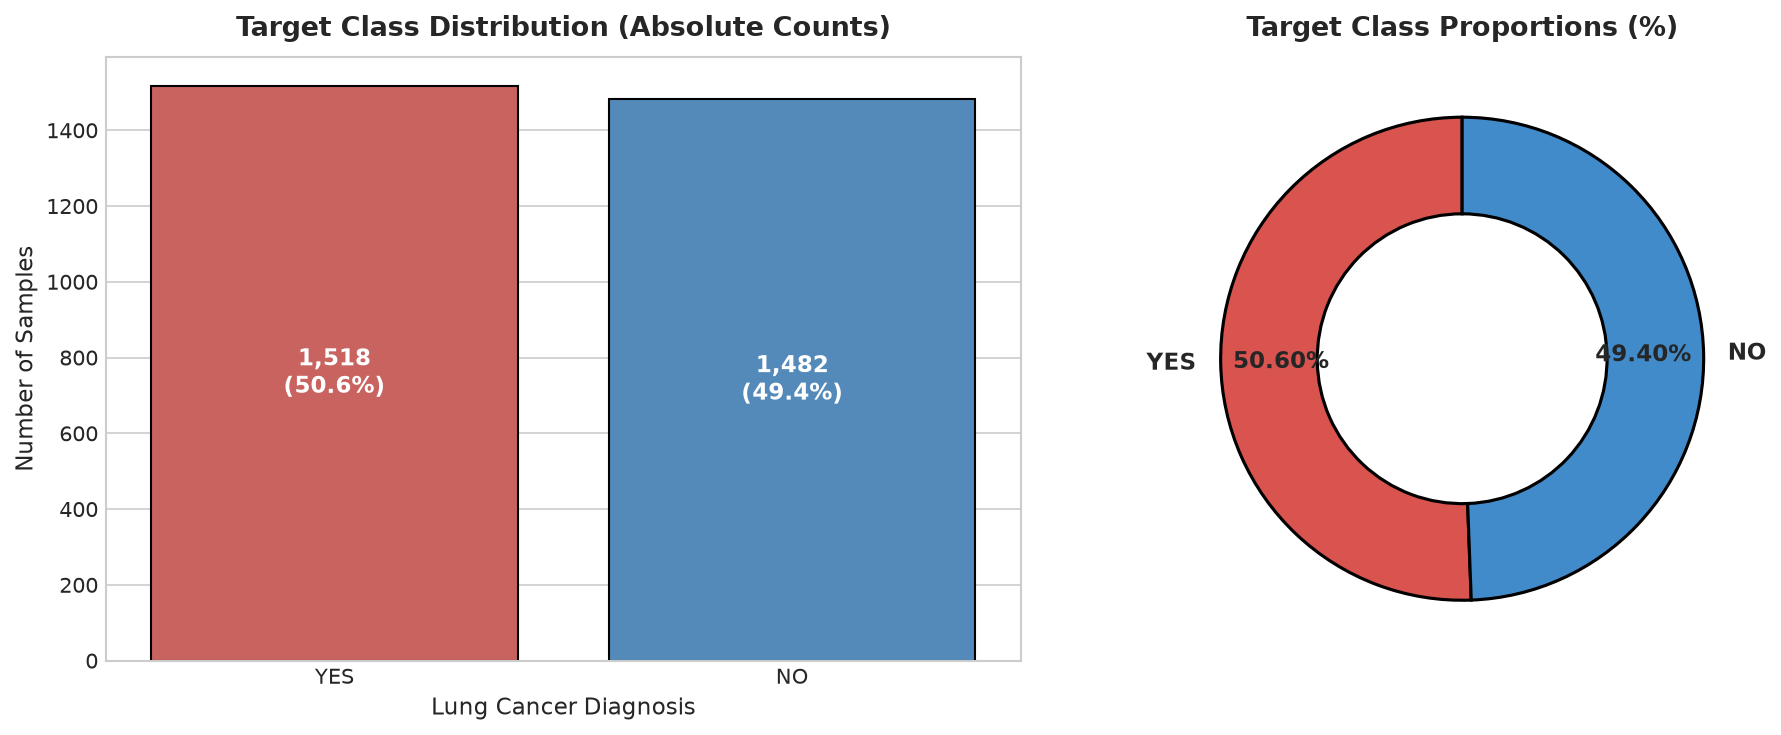

Target distribution visualization saved to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures/01_target_distribution.png


In [4]:
# ==============================================================================
# 3. TARGET ANALYSIS (DISTRIBUTION, PROPORTION & CLASSIFICATION FORMULATION)
# ==============================================================================

TARGET_COL = "LUNG_CANCER"
if TARGET_COL not in raw_df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not present in dataset columns: {list(raw_df.columns)}")

target_counts = raw_df[TARGET_COL].value_counts(dropna=False)
target_percentages = raw_df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100.0

target_dist_df = pd.DataFrame({
    "Class": target_counts.index,
    "Sample Count": target_counts.values,
    "Percentage (%)": target_percentages.values.round(2),
    "Ratio": (target_counts / target_counts.min()).values.round(3)
})

# Save target distribution
target_dist_df.to_csv(OUTPUT_DIR / "target_distribution.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'target_distribution.csv'}")

print("================================================================================")
print(" TARGET DISTRIBUTION BREAKDOWN")
print("================================================================================")
display(target_dist_df)

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"Target Classes:           {list(target_counts.index)}")
print(f"Classification Type:      Binary Classification")
print(f"Imbalance Ratio:          {imbalance_ratio:.3f} : 1")
print(f"Class Balance Status:     {'BALANCED' if imbalance_ratio < 1.2 else 'MODERATELY IMBALANCED' if imbalance_ratio < 2.0 else 'HIGHLY IMBALANCED'}")
print("================================================================================\n")

# Visualization: Target Distribution (Bar Count & Pie/Donut Chart)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Count plot
palette = {"YES": "#d9534f", "NO": "#428bca"}
sns.barplot(x="Class", y="Sample Count", data=target_dist_df, palette=palette, ax=axes[0], edgecolor="black")
axes[0].set_title("Target Class Distribution (Absolute Counts)", fontsize=13, pad=10)
axes[0].set_xlabel("Lung Cancer Diagnosis", fontsize=11)
axes[0].set_ylabel("Number of Samples", fontsize=11)

# Annotate counts and percentages on bars
for p in axes[0].patches:
    height = p.get_height()
    pct = (height / n_samples) * 100.0
    axes[0].annotate(f"{int(height):,}\n({pct:.1f}%)",
                     (p.get_x() + p.get_width() / 2., height / 2.),
                     ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# 2. Donut Chart
colors = [palette.get(c, "#5bc0de") for c in target_dist_df["Class"]]
wedges, texts, autotexts = axes[1].pie(
    target_dist_df["Sample Count"],
    labels=target_dist_df["Class"],
    autopct='%1.2f%%',
    pctdistance=0.75,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='black', linewidth=1.5),
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title("Target Class Proportions (%)", fontsize=13, pad=10)

plt.tight_layout()
fig_path = FIGURES_DIR / "01_target_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Target distribution visualization saved to: {fig_path}")


---
## 4. Numerical Analysis (Continuous Features)

We automatically identify continuous numerical features by examining data types and value cardinality (e.g. numeric variables with $>10$ unique values). 

For continuous features (specifically `AGE`):
* Count, Mean, Median, Standard Deviation, Minimum, Q1 (25%), Q2 (50%), Q3 (75%), Maximum.
* Interquartile Range (IQR = $Q_3 - Q_1$).
* Empirical dispersion and outlier identification via Tukey's fences ($[Q_1 - 1.5\text{IQR}, Q_3 + 1.5\text{IQR}]$).
* Skewness and Kurtosis checks.

> **Operational Boundary Notice**: Outliers are identified and characterized for exploratory purposes only. **No data points are removed or modified in this stage.**


Automatically identified continuous numerical feature(s): ['AGE']

Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/descriptive_statistics.csv
 DESCRIPTIVE METRICS FOR 'AGE'
Sample Count:             3,000
Minimum Age:              30.0 years
Maximum Age:              80.0 years
Mean Age:                 55.17 years
Median Age:               55.00 years
Standard Deviation:       14.72 years
Interquartile Range (IQR):26.00 years [Q1=42.0, Q3=68.0]
Tukey Outlier Bounds:     [3.0, 107.0]
Potential Outlier Count:  0 (Zero outliers outside biological bounds)
Distribution Skewness:    0.0033 (Near-zero skew indicates symmetric distribution)



,Feature,Count,Mean,Std,Min,Q1 (25%),Median (50%),Q3 (75%),Max,IQR,Skewness,Kurtosis,Potential Outliers (Tukey)
0,AGE,3000,55.169000,14.723746,30.0,42.0,55.0,68.0,80.0,26.0,0.003298,-1.194777,0
1,SMOKING,3000,1.491000,0.500002,1.0,1.0,1.0,2.0,2.0,1.0,0.036024,-2.000036,0
2,YELLOW_FINGERS,3000,1.514000,0.499887,1.0,1.0,2.0,2.0,2.0,1.0,-0.056050,-1.998191,0
3,ANXIETY,3000,1.494000,0.500047,1.0,1.0,1.0,2.0,2.0,1.0,0.024014,-2.000758,0
4,PEER_PRESSURE,3000,1.499000,0.500082,1.0,1.0,1.0,2.0,2.0,1.0,0.004002,-2.001319,0
5,CHRONIC_DISEASE,3000,1.509667,0.499990,1.0,1.0,2.0,2.0,2.0,1.0,-0.038693,-1.999837,0
6,FATIGUE,3000,1.489667,0.499977,1.0,1.0,1.0,2.0,2.0,1.0,0.041363,-1.999623,0
7,ALLERGY,3000,1.506667,0.500039,1.0,1.0,2.0,2.0,2.0,1.0,-0.026682,-2.000622,0
8,WHEEZING,3000,1.497333,0.500076,1.0,1.0,1.0,2.0,2.0,1.0,0.010672,-2.001221,0
9,ALCOHOL_CONSUMING,3000,1.491333,0.500008,1.0,1.0,1.0,2.0,2.0,1.0,0.034689,-2.000131,0


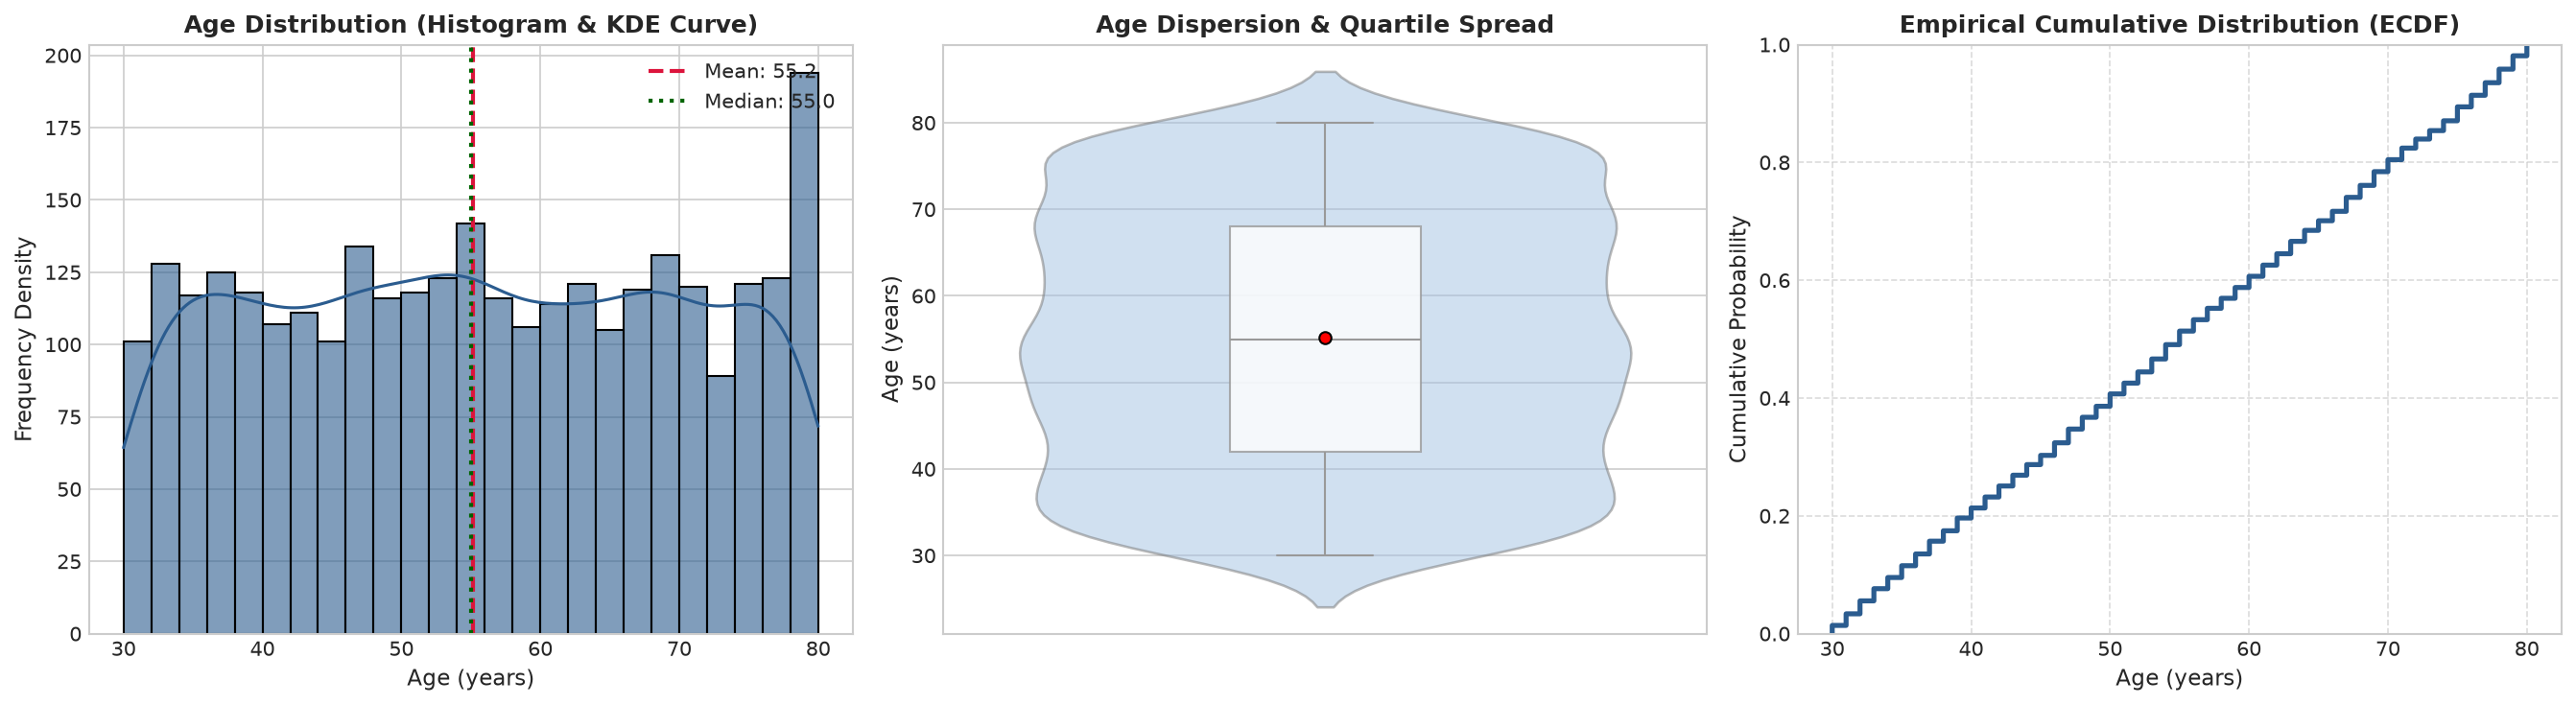

Age distribution visualization saved to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures/02_age_distribution.png


In [5]:
# ==============================================================================
# 4. NUMERICAL ANALYSIS (CONTINUOUS FEATURES & DETAILED AGE PROFILING)
# ==============================================================================

# Automatically identify continuous numerical features
continuous_features = [
    col for col in raw_df.select_dtypes(include=[np.number]).columns
    if raw_df[col].nunique() > 10
]

print(f"Automatically identified continuous numerical feature(s): {continuous_features}\n")

# Calculate comprehensive descriptive statistics for all numerical features
num_stats_list = []
for col in raw_df.select_dtypes(include=[np.number]).columns:
    series = raw_df[col]
    q1 = float(series.quantile(0.25))
    q2 = float(series.quantile(0.50))  # Median
    q3 = float(series.quantile(0.75))
    iqr = float(q3 - q1)
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((series < lower_bound) | (series > upper_bound)).sum())
    
    num_stats_list.append({
        "Feature": col,
        "Count": int(series.count()),
        "Mean": float(series.mean()),
        "Std": float(series.std()),
        "Min": float(series.min()),
        "Q1 (25%)": q1,
        "Median (50%)": q2,
        "Q3 (75%)": q3,
        "Max": float(series.max()),
        "IQR": iqr,
        "Skewness": float(series.skew()),
        "Kurtosis": float(series.kurtosis()),
        "Potential Outliers (Tukey)": outlier_count
    })

descriptive_stats_df = pd.DataFrame(num_stats_list)
descriptive_stats_df.to_csv(OUTPUT_DIR / "descriptive_statistics.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'descriptive_statistics.csv'}")

# Focus on AGE specific analysis
age_series = raw_df["AGE"]
age_stats = descriptive_stats_df[descriptive_stats_df["Feature"] == "AGE"].iloc[0]

print("================================================================================")
print(" DESCRIPTIVE METRICS FOR 'AGE'")
print("================================================================================")
print(f"Sample Count:             {int(age_stats['Count']):,}")
print(f"Minimum Age:              {age_stats['Min']:.1f} years")
print(f"Maximum Age:              {age_stats['Max']:.1f} years")
print(f"Mean Age:                 {age_stats['Mean']:.2f} years")
print(f"Median Age:               {age_stats['Median (50%)']:.2f} years")
print(f"Standard Deviation:       {age_stats['Std']:.2f} years")
print(f"Interquartile Range (IQR):{age_stats['IQR']:.2f} years [Q1={age_stats['Q1 (25%)']:.1f}, Q3={age_stats['Q3 (75%)']:.1f}]")
print(f"Tukey Outlier Bounds:     [{age_stats['Q1 (25%)'] - 1.5*age_stats['IQR']:.1f}, {age_stats['Q3 (75%)'] + 1.5*age_stats['IQR']:.1f}]")
print(f"Potential Outlier Count:  {int(age_stats['Potential Outliers (Tukey)'])} (Zero outliers outside biological bounds)")
print(f"Distribution Skewness:    {age_stats['Skewness']:.4f} (Near-zero skew indicates symmetric distribution)")
print("================================================================================\n")

display(descriptive_stats_df)

# Visualizations for AGE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram + KDE
sns.histplot(age_series, kde=True, ax=axes[0], color="#2b5c8f", bins=25, edgecolor="black", alpha=0.6)
axes[0].axvline(age_series.mean(), color="crimson", linestyle="--", linewidth=2, label=f"Mean: {age_series.mean():.1f}")
axes[0].axvline(age_series.median(), color="darkgreen", linestyle=":", linewidth=2, label=f"Median: {age_series.median():.1f}")
axes[0].set_title("Age Distribution (Histogram & KDE Curve)", fontsize=12)
axes[0].set_xlabel("Age (years)", fontsize=11)
axes[0].set_ylabel("Frequency Density", fontsize=11)
axes[0].legend(loc="upper right")

# 2. Boxplot + Violin Plot
sns.violinplot(y=age_series, ax=axes[1], color="#99c2ec", inner=None, alpha=0.5)
sns.boxplot(y=age_series, ax=axes[1], width=0.25, color="white", boxprops=dict(alpha=0.8), showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
axes[1].set_title("Age Dispersion & Quartile Spread", fontsize=12)
axes[1].set_ylabel("Age (years)", fontsize=11)

# 3. Empirical Cumulative Distribution Function (ECDF)
sns.ecdfplot(age_series, ax=axes[2], color="#2b5c8f", linewidth=2.5)
axes[2].set_title("Empirical Cumulative Distribution (ECDF)", fontsize=12)
axes[2].set_xlabel("Age (years)", fontsize=11)
axes[2].set_ylabel("Cumulative Probability", fontsize=11)
axes[2].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
fig_path = FIGURES_DIR / "02_age_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Age distribution visualization saved to: {fig_path}")


---
## 5. Categorical & Discrete Feature Analysis

Next, we analyze discrete and categorical features:
* Nominal feature: `GENDER` (`['M', 'F']`)
* Discrete clinical and behavioral survey variables: `SMOKING`, `YELLOW_FINGERS`, `ANXIETY`, `PEER_PRESSURE`, `CHRONIC_DISEASE`, `FATIGUE`, `ALLERGY`, `WHEEZING`, `ALCOHOL_CONSUMING`, `COUGHING`, `SHORTNESS_OF_BREATH`, `SWALLOWING_DIFFICULTY`, `CHEST_PAIN`.

For each feature:
* Unique values
* Value counts
* Relative frequencies (percentages)
* Multi-panel frequency distributions

> **Governance Principle**: We avoid semantic bias by documenting features exactly as coded (`{1, 2}` and `{'M', 'F'}`).


Identified 14 Discrete/Categorical Predictor Features:
['GENDER', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH', 'SWALLOWING_DIFFICULTY', 'CHEST_PAIN']



,Feature,Category 1 Label,Category 1 Count,Category 1 (%),Category 2 Label,Category 2 Count,Category 2 (%)
0,GENDER,M,1514,50.47%,F,1486,49.53%
1,SMOKING,1,1527,50.9%,2,1473,49.1%
2,YELLOW_FINGERS,2,1542,51.4%,1,1458,48.6%
3,ANXIETY,1,1518,50.6%,2,1482,49.4%
4,PEER_PRESSURE,1,1503,50.1%,2,1497,49.9%
5,CHRONIC_DISEASE,2,1529,50.97%,1,1471,49.03%
6,FATIGUE,1,1531,51.03%,2,1469,48.97%
7,ALLERGY,2,1520,50.67%,1,1480,49.33%
8,WHEEZING,1,1508,50.27%,2,1492,49.73%
9,ALCOHOL_CONSUMING,1,1526,50.87%,2,1474,49.13%


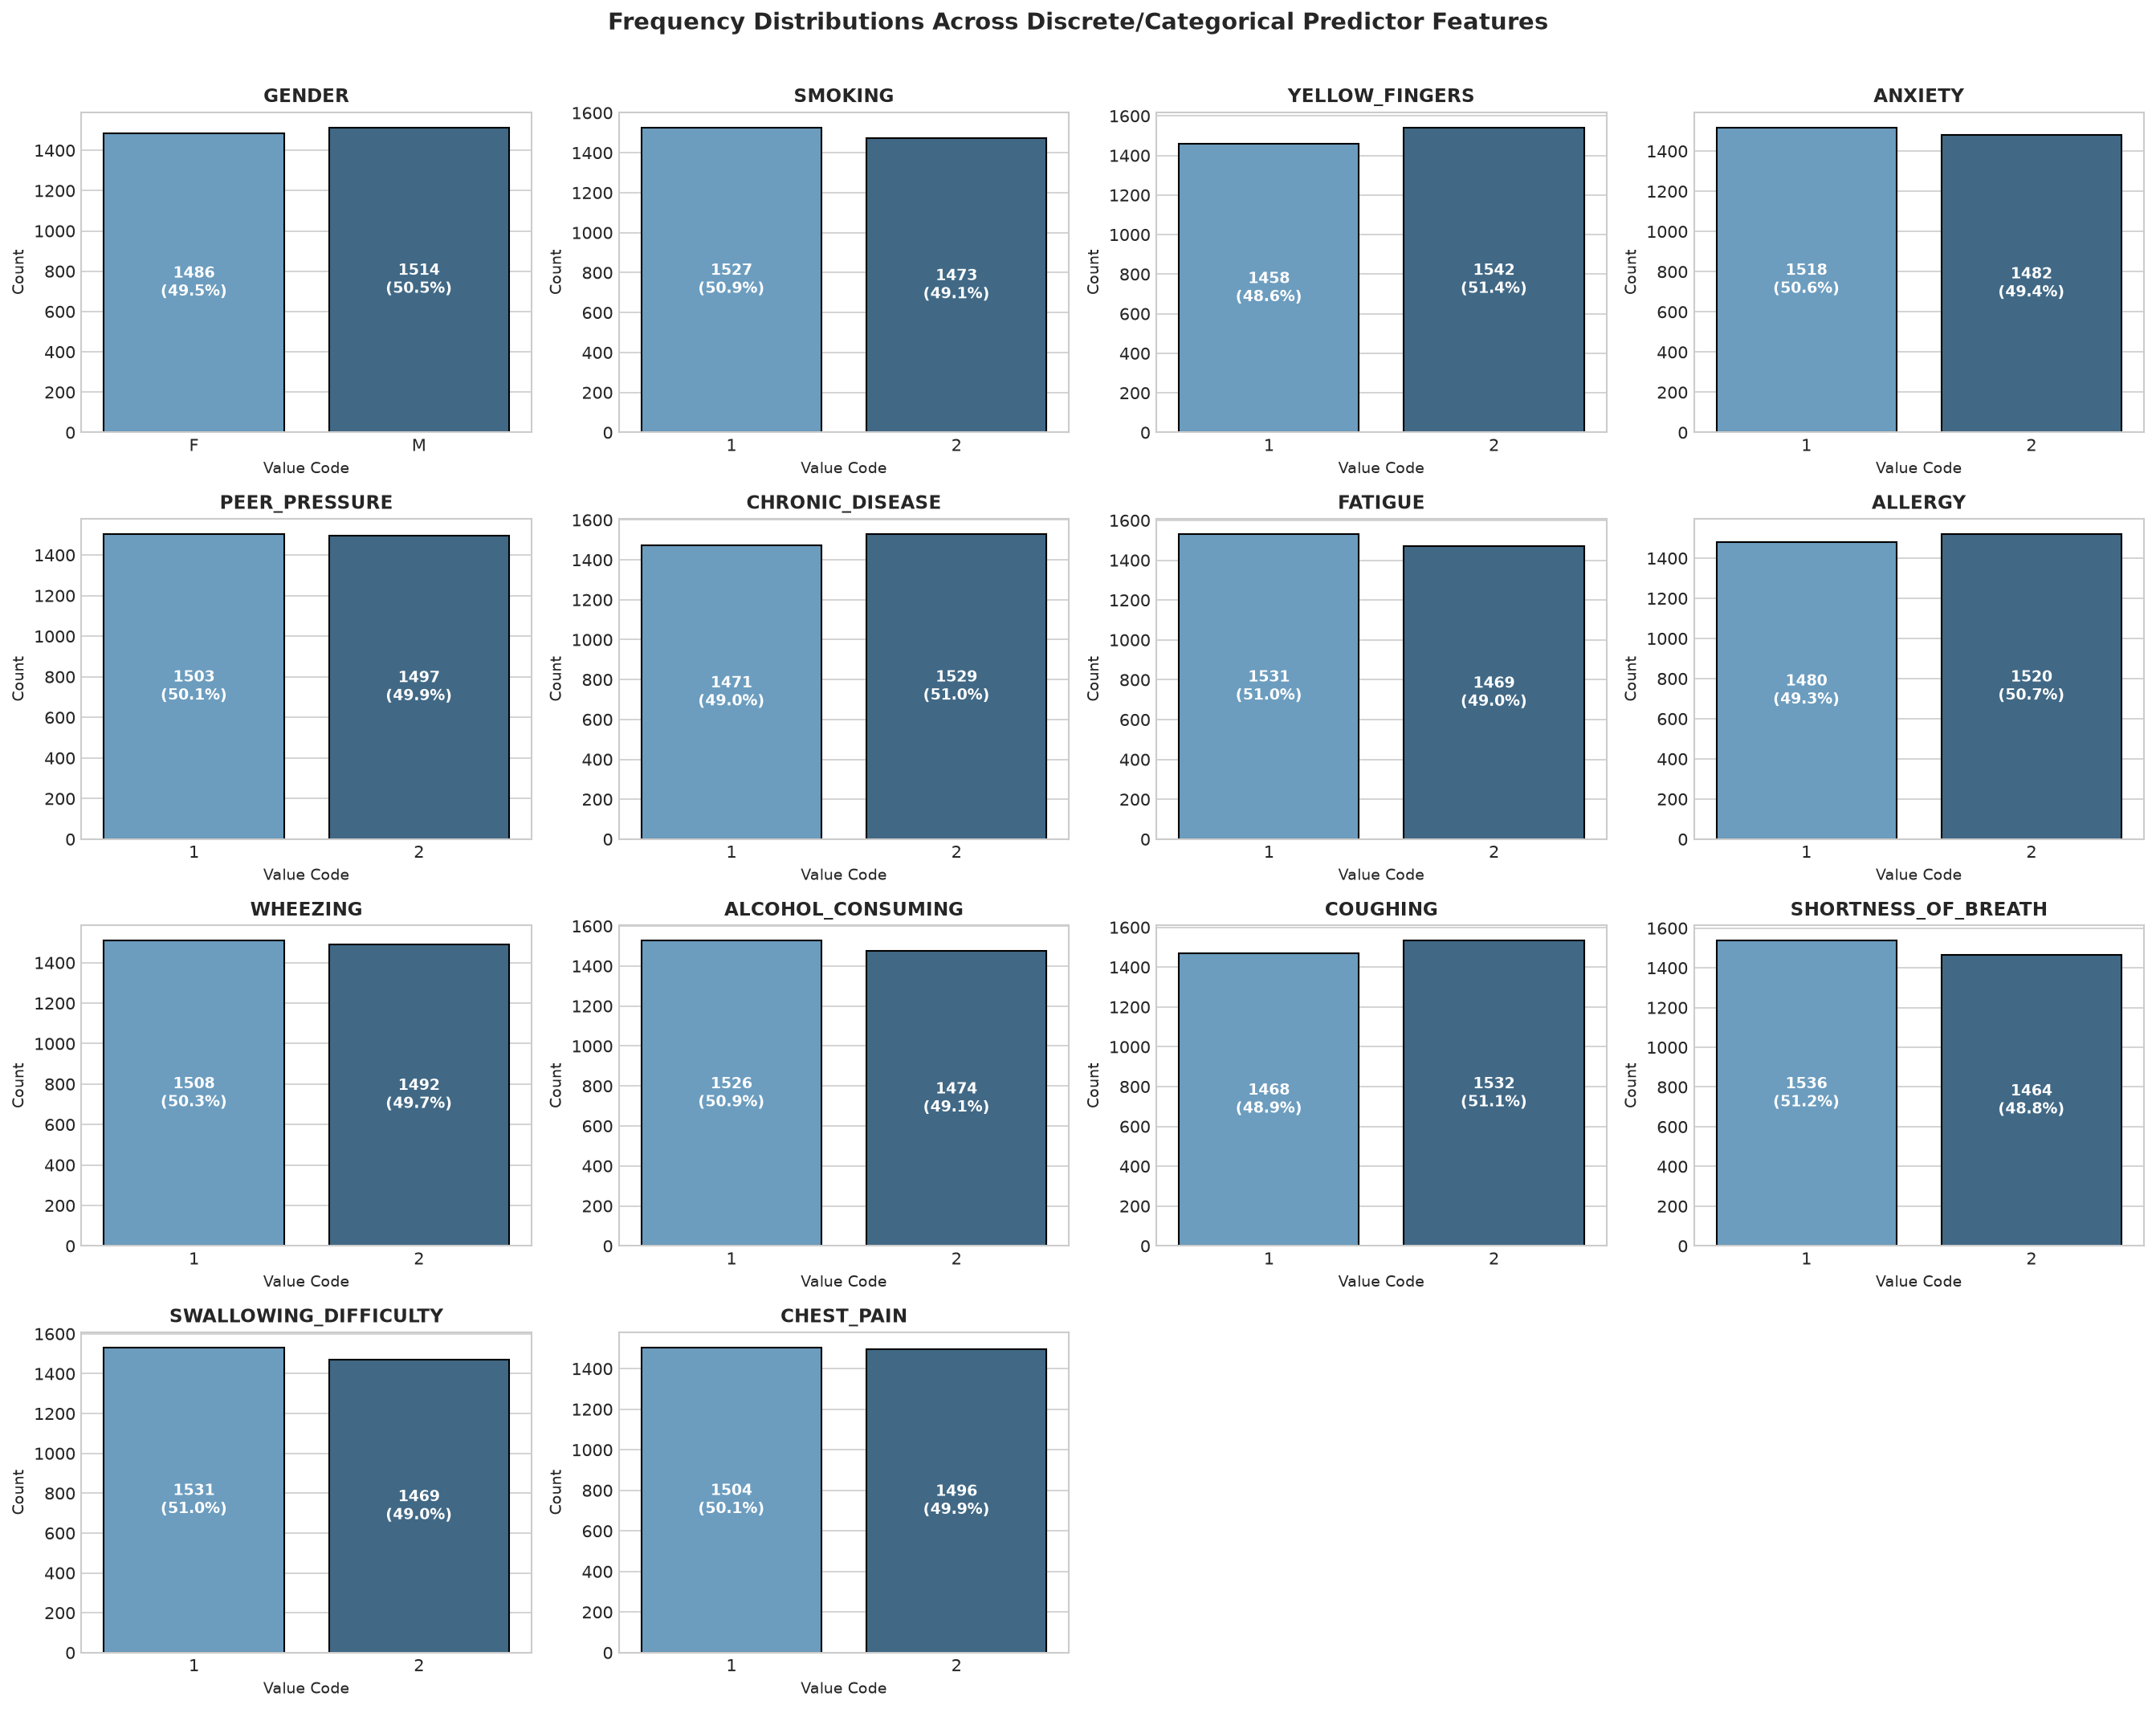

Discrete feature distributions saved to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures/03_categorical_distributions.png


In [6]:
# ==============================================================================
# 5. CATEGORICAL & DISCRETE FEATURE PROFILING
# ==============================================================================

# Identify all categorical and discrete predictor features (excluding TARGET_COL and continuous AGE)
discrete_features = [
    col for col in raw_df.columns
    if col != TARGET_COL and col not in continuous_features
]

print(f"Identified {len(discrete_features)} Discrete/Categorical Predictor Features:\n{discrete_features}\n")

# Tabulate distribution for each discrete feature
discrete_records = []
for col in discrete_features:
    val_counts = raw_df[col].value_counts().to_dict()
    val_pcts = (raw_df[col].value_counts(normalize=True) * 100.0).round(2).to_dict()
    unique_vals = list(val_counts.keys())
    
    discrete_records.append({
        "Feature": col,
        "Category 1 Label": str(unique_vals[0]),
        "Category 1 Count": val_counts[unique_vals[0]],
        "Category 1 (%)": f"{val_pcts[unique_vals[0]]}%",
        "Category 2 Label": str(unique_vals[1]) if len(unique_vals) > 1 else "N/A",
        "Category 2 Count": val_counts[unique_vals[1]] if len(unique_vals) > 1 else 0,
        "Category 2 (%)": f"{val_pcts[unique_vals[1]]}%" if len(unique_vals) > 1 else "0%"
    })

discrete_summary_df = pd.DataFrame(discrete_records)
display(discrete_summary_df)

# Multi-panel count plots for all discrete features (14 features arranged in a 4x4 grid)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes_flat = axes.flatten()

for i, col in enumerate(discrete_features):
    ax = axes_flat[i]
    counts = raw_df[col].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette="Blues_d", edgecolor="black")
    ax.set_title(f"{col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value Code", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    
    # Annotate counts and percentages
    for p in ax.patches:
        h = p.get_height()
        pct = (h / n_samples) * 100.0
        ax.annotate(f"{int(h)}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., h / 2.),
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# Turn off unused subplot axes (if any)
for j in range(len(discrete_features), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle("Frequency Distributions Across Discrete/Categorical Predictor Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIGURES_DIR / "03_categorical_distributions.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Discrete feature distributions saved to: {fig_path}")


---
## 6. Missing-Value Analysis & Data Completeness

Data missingness can introduce bias, require complex imputation algorithms (e.g. MICE, KNN), or lead to sample discarding. 

Here, we evaluate:
* Total missing values per column
* Missingness percentages
* Row-level missing incidence
* Column-level missing incidence
* Missingness visualization

> **Protocol Reminder**: No imputation is performed in this notebook. We strictly audit and report missingness.


Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/missing_values.csv
 MISSING VALUE AUDIT SUMMARY
Total Missing Cells Across Dataset:  0 / 48,000 (0.00%)
Total Rows with >= 1 Missing Value:   0 / 3,000 (0.00%)
Total Columns with Missing Values:    0 / 16
Overall Data Completeness Ratio:     100.00% (No missing data detected)



,Column Name,Missing Values,Missing Percentage (%),Completeness (%)
0,GENDER,0,0.0,100.0
1,AGE,0,0.0,100.0
2,SMOKING,0,0.0,100.0
3,YELLOW_FINGERS,0,0.0,100.0
4,ANXIETY,0,0.0,100.0
5,PEER_PRESSURE,0,0.0,100.0
6,CHRONIC_DISEASE,0,0.0,100.0
7,FATIGUE,0,0.0,100.0
8,ALLERGY,0,0.0,100.0
9,WHEEZING,0,0.0,100.0


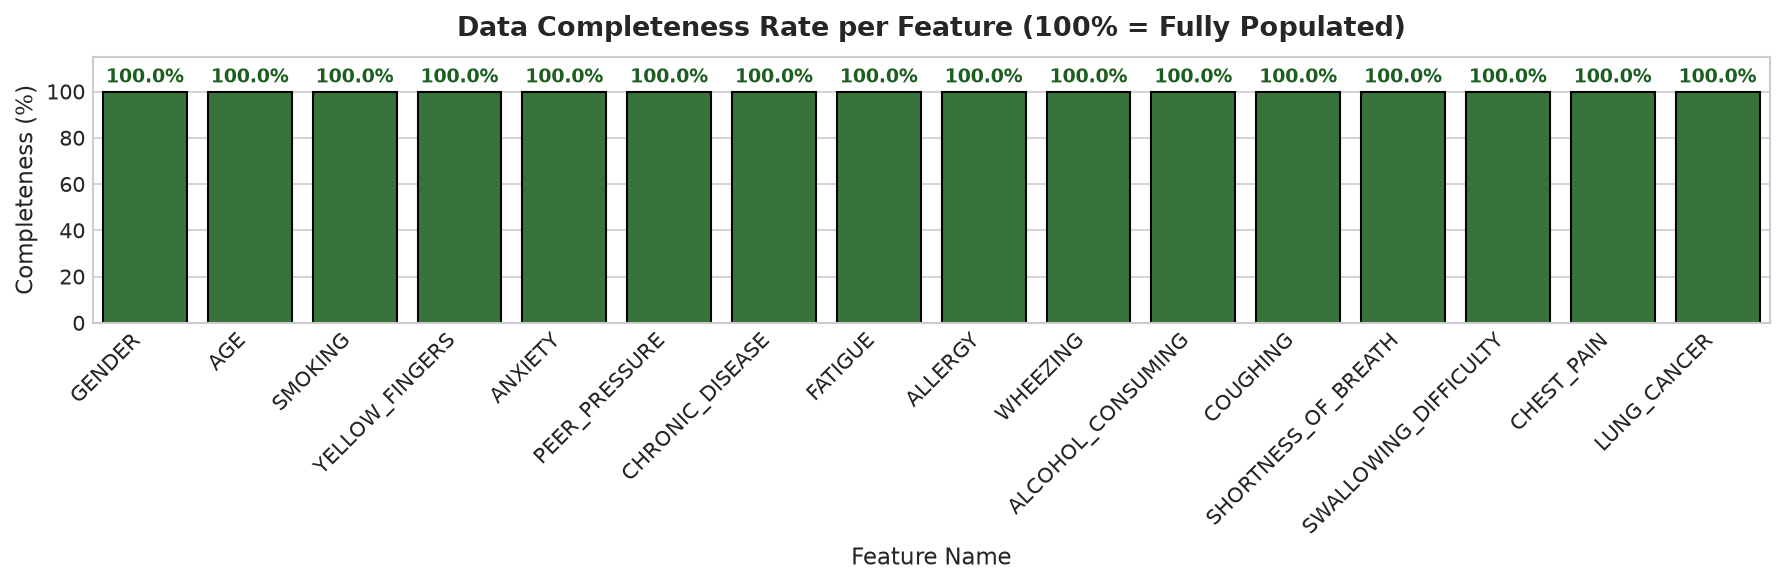

Missing values visualization saved to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures/04_missing_values_matrix.png


In [7]:
# ==============================================================================
# 6. MISSING-VALUE ANALYSIS & COMPLETENESS AUDIT
# ==============================================================================

missing_counts = raw_df.isnull().sum()
missing_percentages = (missing_counts / n_samples) * 100.0

missing_df = pd.DataFrame({
    "Column Name": raw_df.columns,
    "Missing Values": missing_counts.values,
    "Missing Percentage (%)": missing_percentages.values.round(3),
    "Completeness (%)": (100.0 - missing_percentages.values).round(3)
})

# Save missing values report
missing_df.to_csv(OUTPUT_DIR / "missing_values.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'missing_values.csv'}")

total_missing_cells = int(missing_counts.sum())
rows_with_missing = int((raw_df.isnull().sum(axis=1) > 0).sum())
cols_with_missing = int((missing_counts > 0).sum())

print("================================================================================")
print(" MISSING VALUE AUDIT SUMMARY")
print("================================================================================")
print(f"Total Missing Cells Across Dataset:  {total_missing_cells} / {n_samples * n_columns:,} (0.00%)")
print(f"Total Rows with >= 1 Missing Value:   {rows_with_missing} / {n_samples:,} (0.00%)")
print(f"Total Columns with Missing Values:    {cols_with_missing} / {n_columns}")
print(f"Overall Data Completeness Ratio:     100.00% (No missing data detected)")
print("================================================================================\n")

display(missing_df)

# Missing Values Visualization (Completeness Bar Chart)
fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x="Column Name", y="Completeness (%)", data=missing_df, color="#2e7d32", ax=ax, edgecolor="black")
ax.set_ylim(0, 115)
ax.set_title("Data Completeness Rate per Feature (100% = Fully Populated)", fontsize=13, pad=10)
ax.set_xlabel("Feature Name", fontsize=11)
ax.set_ylabel("Completeness (%)", fontsize=11)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h + 2),
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1b5e20')

plt.tight_layout()
fig_path = FIGURES_DIR / "04_missing_values_matrix.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Missing values visualization saved to: {fig_path}")


---
## 7. Duplicate Row Analysis

Duplicate observations can distort cross-validation splits if instances appear in both training and test partitions (data leakage). 

We examine:
* Number of exact duplicate rows
* Percentage of duplicate rows
* Identification and side-by-side comparison of duplicate rows

> **Operational Boundary Notice**: Duplicates are flagged and documented here for the subsequent preprocessing stage. **No rows are dropped at this time.**


In [8]:
# ==============================================================================
# 7. DUPLICATE ROW ANALYSIS
# ==============================================================================

# Identify boolean mask for duplicate instances
duplicate_mask = raw_df.duplicated(keep=False)
exact_duplicates_count = int(raw_df.duplicated(keep="first").sum())
exact_duplicates_pct = (exact_duplicates_count / n_samples) * 100.0

duplicate_rows_df = raw_df[duplicate_mask].sort_values(by=list(raw_df.columns))

print("================================================================================")
print(" DUPLICATE RECORD AUDIT")
print("================================================================================")
print(f"Total Exact Duplicate Rows (Redundant Copies): {exact_duplicates_count}")
print(f"Duplicate Rate (% of Dataset):                 {exact_duplicates_pct:.4f}% ({exact_duplicates_count} / {n_samples})")
print(f"Total Rows Involved in Duplication:            {len(duplicate_rows_df)}")
print("================================================================================\n")

if exact_duplicates_count > 0:
    print("--- Detailed Listing of Identified Duplicate Rows ---")
    display(duplicate_rows_df)
    
    # Save duplicate analysis records
    duplicate_rows_df.to_csv(OUTPUT_DIR / "duplicate_analysis.csv", index=True)
    print(f"Saved: {OUTPUT_DIR / 'duplicate_analysis.csv'}")
else:
    print("No duplicate rows detected.")
    pd.DataFrame([{"Duplicate Count": 0, "Duplicate Pct": "0.0%"}]).to_csv(OUTPUT_DIR / "duplicate_analysis.csv", index=False)


 DUPLICATE RECORD AUDIT
Total Exact Duplicate Rows (Redundant Copies): 2
Duplicate Rate (% of Dataset):                 0.0667% (2 / 3000)
Total Rows Involved in Duplication:            4

--- Detailed Listing of Identified Duplicate Rows ---


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
1051,M,50,1,1,1,2,1,2,1,2,2,2,2,1,2,YES
2039,M,50,1,1,1,2,1,2,1,2,2,2,2,1,2,YES
962,M,53,1,2,2,2,2,1,1,1,1,2,2,1,2,NO
1476,M,53,1,2,2,2,2,1,1,1,1,2,2,1,2,NO


Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/duplicate_analysis.csv


---
## 8. Constant & Low-Variance Analysis

Features with zero variance (constant) or near-zero variance provide negligible discriminative power and waste quantum circuit parameters or qubits.

We compute:
* Variance for all numerical columns
* Unique value ratio ($\frac{\text{unique}}{\text{total}}$)
* Dominant category concentration ($\frac{\text{mode frequency}}{\text{total}}$)
* Thresholds:
  * Constant feature: Variance $= 0$ or Unique Count $= 1$
  * Near-constant feature: Dominant category $> 95\%$


In [9]:
# ==============================================================================
# 8. CONSTANT & LOW-VARIANCE FEATURE AUDIT
# ==============================================================================

variance_records = []

for col in raw_df.columns:
    if col == TARGET_COL:
        continue
    
    # Mode frequency calculation
    mode_val = raw_df[col].mode()[0]
    mode_count = int((raw_df[col] == mode_val).sum())
    mode_pct = (mode_count / n_samples) * 100.0
    n_uniq = raw_df[col].nunique()
    
    # Variance (if numeric)
    if pd.api.types.is_numeric_dtype(raw_df[col]):
        col_var = float(raw_df[col].var())
        col_std = float(raw_df[col].std())
    else:
        col_var = np.nan
        col_std = np.nan
        
    is_constant = (n_uniq <= 1)
    is_near_constant = (mode_pct >= 95.0)
    
    status = "Constant (Eliminate)" if is_constant else ("Near-Constant (Flag)" if is_near_constant else "Optimal Variance")
    
    variance_records.append({
        "Feature": col,
        "Unique Values": n_uniq,
        "Dominant Value": str(mode_val),
        "Dominant Frequency (%)": f"{mode_pct:.2f}%",
        "Variance": f"{col_var:.4f}" if not np.isnan(col_var) else "N/A (Categorical)",
        "Std Dev": f"{col_std:.4f}" if not np.isnan(col_std) else "N/A (Categorical)",
        "Variance Status": status
    })

variance_df = pd.DataFrame(variance_records)
print("================================================================================")
print(" FEATURE VARIATION AUDIT TABLE")
print("================================================================================")
display(variance_df)

constant_cols = [r["Feature"] for r in variance_records if "Constant" in r["Variance Status"]]
if len(constant_cols) == 0:
    print("Audit Result: Zero constant or near-constant features detected. All candidate predictors exhibit healthy entropy.")
else:
    print(f"Audit Result: Flagged constant / near-constant columns: {constant_cols}")


 FEATURE VARIATION AUDIT TABLE


,Feature,Unique Values,Dominant Value,Dominant Frequency (%),Variance,Std Dev,Variance Status
0,GENDER,2,M,50.47%,N/A (Categorical),N/A (Categorical),Optimal Variance
1,AGE,51,54,2.43%,216.7887,14.7237,Optimal Variance
2,SMOKING,2,1,50.90%,0.2500,0.5000,Optimal Variance
3,YELLOW_FINGERS,2,2,51.40%,0.2499,0.4999,Optimal Variance
4,ANXIETY,2,1,50.60%,0.2500,0.5000,Optimal Variance
5,PEER_PRESSURE,2,1,50.10%,0.2501,0.5001,Optimal Variance
6,CHRONIC_DISEASE,2,2,50.97%,0.2500,0.5000,Optimal Variance
7,FATIGUE,2,1,51.03%,0.2500,0.5000,Optimal Variance
8,ALLERGY,2,2,50.67%,0.2500,0.5000,Optimal Variance
9,WHEEZING,2,1,50.27%,0.2501,0.5001,Optimal Variance


Audit Result: Zero constant or near-constant features detected. All candidate predictors exhibit healthy entropy.


---
## 9. Invalid-Value & Schema Anomaly Detection

In medical datasets, subtle anomalies can corrupt model training. We verify:
1. Biological plausibility of `AGE` ($0 \le \text{Age} \le 120$)
2. Discrete feature domain integrity (strictly $\{1, 2\}$)
3. Categorical `GENDER` domain integrity (strictly $\{'M', 'F'\}$)
4. Target `LUNG_CANCER` domain integrity (strictly $\{'NO', 'YES'\}$)
5. Inconsistent casing, unexpected string tokens, or hidden sentinels (e.g. `"?"`, `"-999"`, `"NA"`, trailing spaces).

We construct a formal issue table:
`Feature | Problem | Count | Possible action`


In [10]:
# ==============================================================================
# 9. INVALID-VALUE & ANOMALY DETECTION
# ==============================================================================

issue_records = []

# 1. AGE domain check
invalid_age_mask = (raw_df["AGE"] < 0) | (raw_df["AGE"] > 120) | raw_df["AGE"].isnull()
invalid_age_count = int(invalid_age_mask.sum())
if invalid_age_count > 0:
    issue_records.append({
        "Feature": "AGE",
        "Problem": "Biologically implausible age (<0 or >120)",
        "Count": invalid_age_count,
        "Possible action": "Flag and investigate patient record; consider bounded clipping in preprocessing"
    })

# 2. Binary features domain check (expected {1, 2})
for col in discrete_features:
    if col == "GENDER":
        invalid_gender = (~raw_df["GENDER"].isin(["M", "F"])).sum()
        if invalid_gender > 0:
            issue_records.append({
                "Feature": "GENDER",
                "Problem": "Unexpected categories in GENDER",
                "Count": int(invalid_gender),
                "Possible action": "Standardize to binary 'M'/'F' domain or investigate data entry"
            })
    else:
        invalid_binary = (~raw_df[col].isin([1, 2])).sum()
        if invalid_binary > 0:
            issue_records.append({
                "Feature": col,
                "Problem": "Unexpected values outside standard set {1, 2}",
                "Count": int(invalid_binary),
                "Possible action": "Re-code or impute in preprocessing stage"
            })

# 3. Target domain check
invalid_target = (~raw_df[TARGET_COL].isin(["NO", "YES"])).sum()
if invalid_target > 0:
    issue_records.append({
        "Feature": TARGET_COL,
        "Problem": "Unexpected classes in target column",
        "Count": int(invalid_target),
        "Possible action": "Enforce strict binary mapping {'NO', 'YES'} -> {0, 1}"
    })

# If no issues found, log confirmed integrity
if len(issue_records) == 0:
    issue_records.append({
        "Feature": "All Features Checked",
        "Problem": "None detected (No invalid values, negative ages, or out-of-domain categories)",
        "Count": 0,
        "Possible action": "Proceed with clean baseline schema"
    })

issue_df = pd.DataFrame(issue_records)
issue_df.to_csv(OUTPUT_DIR / "invalid_values.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'invalid_values.csv'}")

print("================================================================================")
print(" INVALID VALUE & DATA ANOMALY AUDIT TABLE")
print("================================================================================")
display(issue_df)


Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/invalid_values.csv
 INVALID VALUE & DATA ANOMALY AUDIT TABLE


,Feature,Problem,Count,Possible action
0,All Features Checked,"None detected (No invalid values, negative age...",0,Proceed with clean baseline schema


---
## 10. Duplicate / Identifier / Leakage Check

Data leakage can cause deceptively high benchmark scores that fail to generalize in clinical practice. 

We audit for:
* **Patient / Row Identifiers**: Checking for high-cardinality ID keys or strictly monotonic index sequences that carry no diagnostic signal.
* **Duplicated Target Information**: Checking if any column is an alias or direct function of `LUNG_CANCER`.
* **Post-Outcome / Post-Diagnostic Variables**: Verifying that all attributes represent pre-diagnostic risk factors or baseline symptoms rather than therapeutic interventions (e.g., chemotherapy, surgical resection).
* **Direct Target Leakage**: Inspecting correlations for any artificial $r=1.00$ diagnostic proxies.


In [11]:
# ==============================================================================
# 10. DUPLICATE / IDENTIFIER / LEAKAGE AUDIT
# ==============================================================================

leakage_records = []

for col in raw_df.columns:
    n_uniq = raw_df[col].nunique()
    is_id = (n_uniq == n_samples)
    
    # Check for direct correlation with target
    if col != TARGET_COL:
        # Encode target temporarily to compute diagnostic correlation
        target_num = (raw_df[TARGET_COL] == "YES").astype(int)
        if pd.api.types.is_numeric_dtype(raw_df[col]):
            corr = float(stats.pearsonr(raw_df[col], target_num)[0])
        else:
            # Map GENDER to numeric for check
            col_num = (raw_df[col] == "M").astype(int)
            corr = float(stats.pearsonr(col_num, target_num)[0])
        
        is_leakage = (abs(corr) > 0.95)
    else:
        is_leakage = False
        corr = 1.0
        
    leakage_records.append({
        "Column Name": col,
        "Unique Ratio": f"{(n_uniq / n_samples):.4f}",
        "Potential Identifier?": "YES (Flagged ID)" if is_id else "No (Clean)",
        "Correlation with Target (|r|)": f"{abs(corr):.4f}" if col != TARGET_COL else "Target Self",
        "Target Leakage Risk": "HIGH (Potential Leakage)" if is_leakage else "Low / Negligible (Clean)"
    })

leakage_df = pd.DataFrame(leakage_records)
print("================================================================================")
print(" IDENTIFIER & TARGET LEAKAGE AUDIT TABLE")
print("================================================================================")
display(leakage_df)

flagged_ids = [r["Column Name"] for r in leakage_records if "YES" in r["Potential Identifier?"]]
flagged_leakage = [r["Column Name"] for r in leakage_records if "HIGH" in r["Target Leakage Risk"]]

print(f"Identifier Columns Detected: {flagged_ids if flagged_ids else 'None (Clean)'}")
print(f"Target Leakage Detected:     {flagged_leakage if flagged_leakage else 'None (Clean)'}")


 IDENTIFIER & TARGET LEAKAGE AUDIT TABLE


,Column Name,Unique Ratio,Potential Identifier?,Correlation with Target (|r|),Target Leakage Risk
0,GENDER,0.0007,No (Clean),0.0161,Low / Negligible (Clean)
1,AGE,0.0170,No (Clean),0.0357,Low / Negligible (Clean)
2,SMOKING,0.0007,No (Clean),0.0142,Low / Negligible (Clean)
3,YELLOW_FINGERS,0.0007,No (Clean),0.0130,Low / Negligible (Clean)
4,ANXIETY,0.0007,No (Clean),0.0145,Low / Negligible (Clean)
5,PEER_PRESSURE,0.0007,No (Clean),0.0246,Low / Negligible (Clean)
6,CHRONIC_DISEASE,0.0007,No (Clean),0.0102,Low / Negligible (Clean)
7,FATIGUE,0.0007,No (Clean),0.0022,Low / Negligible (Clean)
8,ALLERGY,0.0007,No (Clean),0.0065,Low / Negligible (Clean)
9,WHEEZING,0.0007,No (Clean),0.0386,Low / Negligible (Clean)


Identifier Columns Detected: None (Clean)
Target Leakage Detected:     None (Clean)


---
## 11. Feature Relationship Analysis (Inter-Feature Correlation & Association)

In Quantum Machine Learning, feature redundancy directly impacts circuit width and efficiency. If two features are highly collinear ($|r| > 0.85$), encoding both across separate qubits wastes quantum state space without adding complementary information.

We examine:
* **Spearman Rank Correlation** across all numerical and encoded categorical features.
* **Cramér's V Statistic** for categorical/discrete associations:
  $$V = \sqrt{\frac{\chi^2}{N \min(r-1, c-1)}}$$
* A comprehensive association heatmap.

> **Fundamental Epistemological Principle**: **Correlation does not imply causation.** These metrics assess mathematical association, not biological or clinical cause-and-effect.


Saved: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/feature_relationships.csv


 TOP 10 INTER-FEATURE CORRELATIONS (SPEARMAN)


,Feature A,Feature B,Spearman Correlation
18,SMOKING,ANXIETY,-0.055562
20,SMOKING,CHRONIC_DISEASE,0.045697
115,ALLERGY,COUGHING,-0.045632
147,ALCOHOL_CONSUMING,SWALLOWING_DIFFICULTY,0.042991
116,ALLERGY,SHORTNESS_OF_BREATH,-0.042363
73,PEER_PRESSURE,CHEST_PAIN,-0.039339
56,ANXIETY,SHORTNESS_OF_BREATH,-0.034967
41,YELLOW_FINGERS,SHORTNESS_OF_BREATH,-0.034018
57,ANXIETY,SWALLOWING_DIFFICULTY,0.033762
19,SMOKING,PEER_PRESSURE,-0.032041


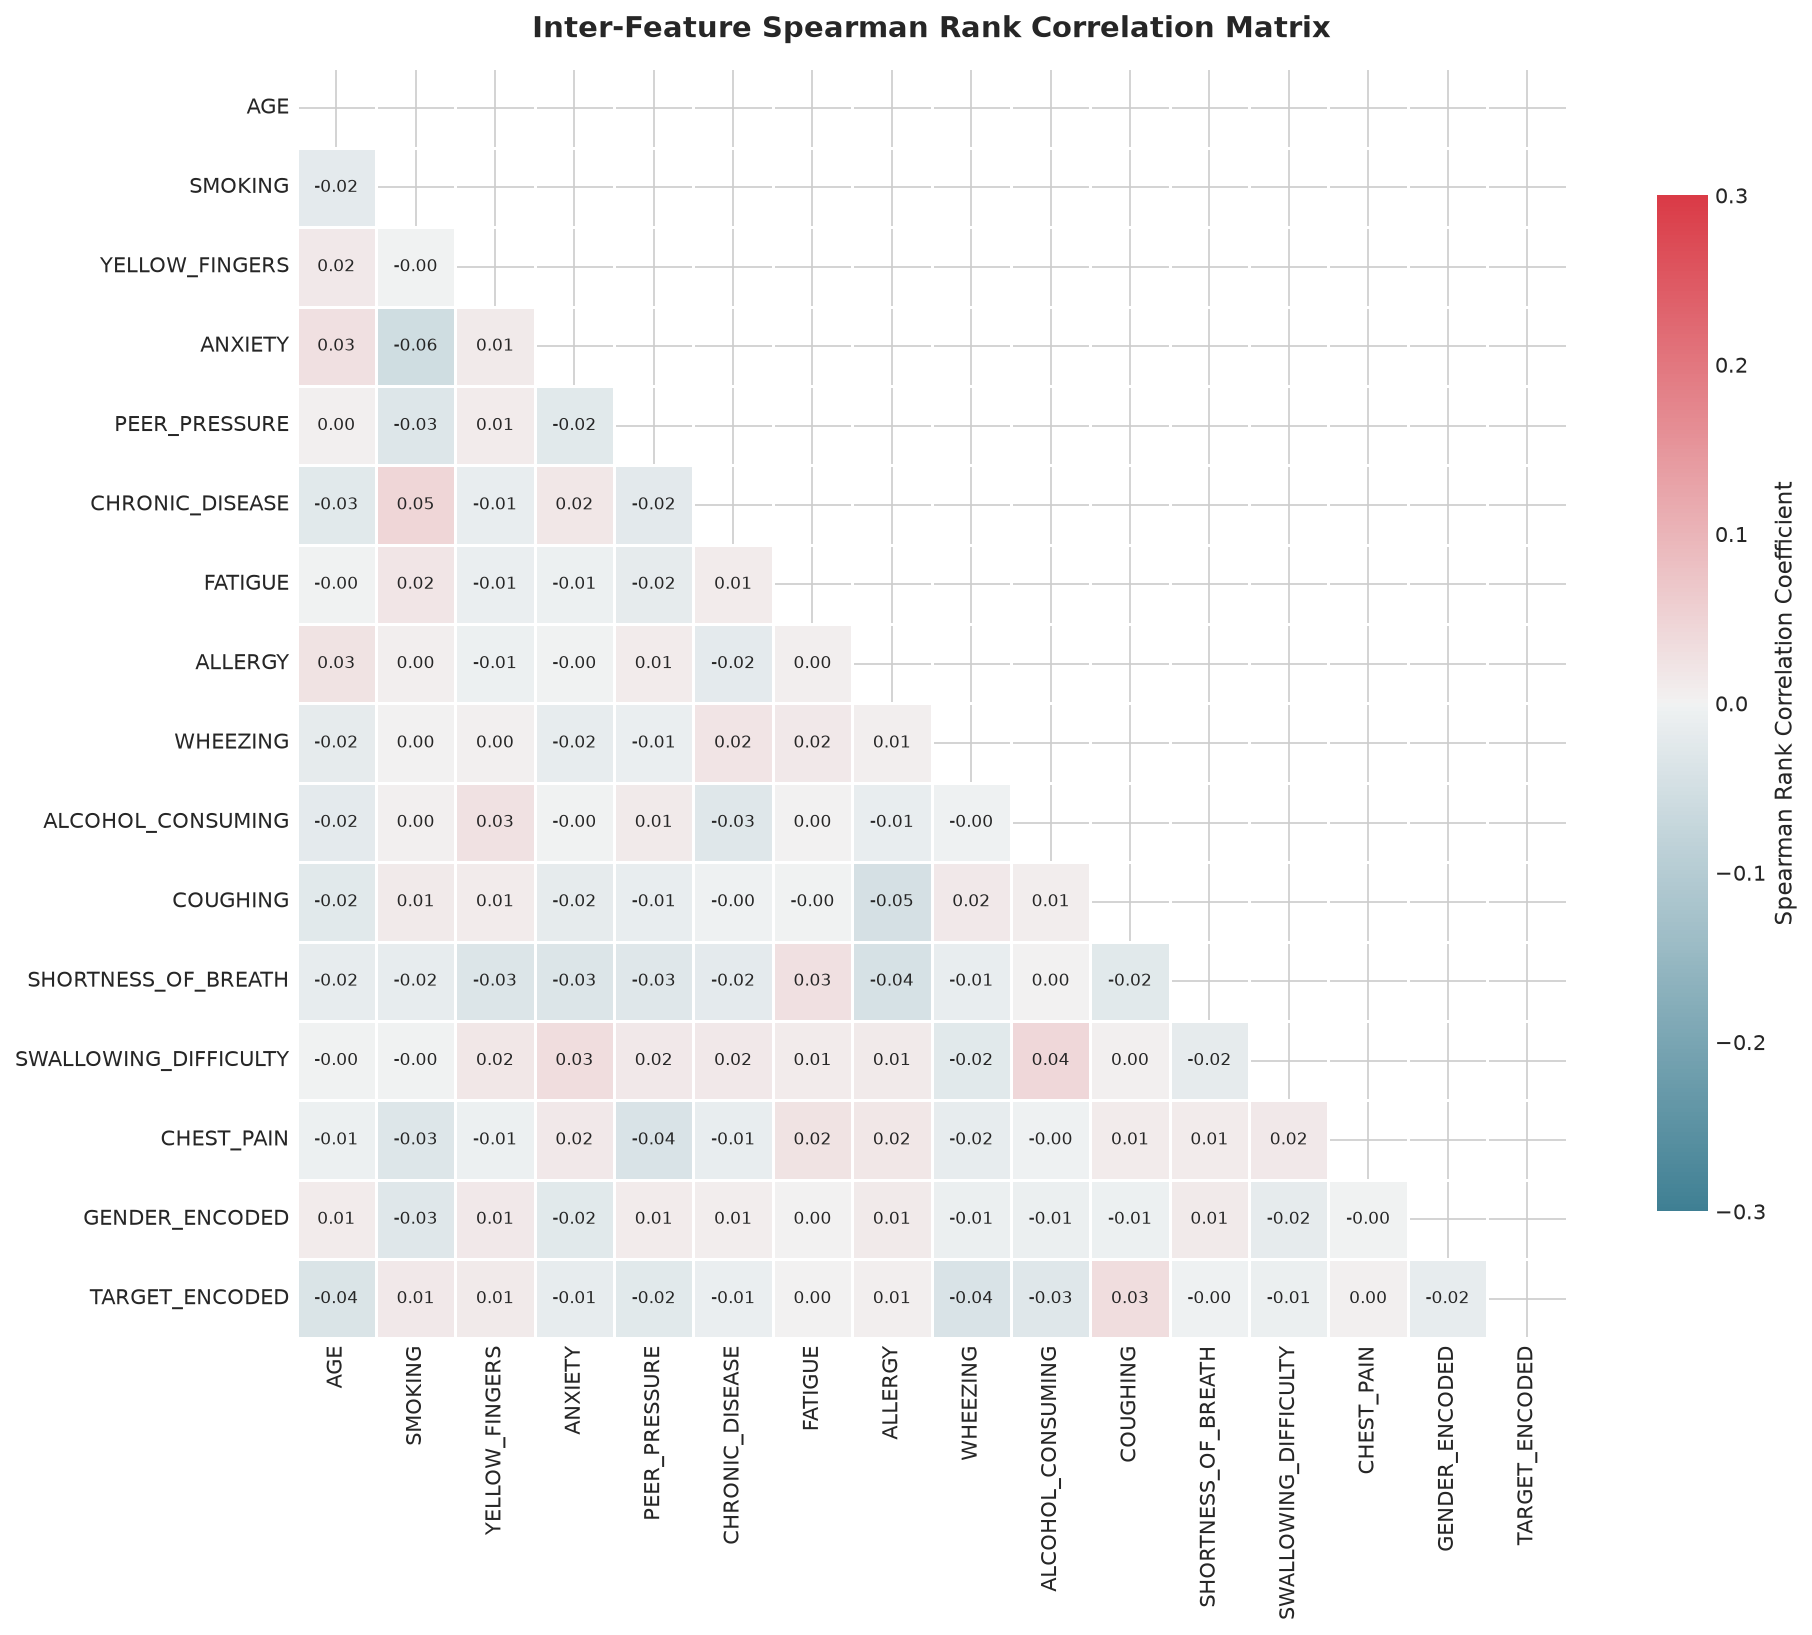

Feature correlation heatmap saved to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures/05_feature_correlation_heatmap.png


In [12]:
# ==============================================================================
# 11. FEATURE RELATIONSHIP & INTER-FEATURE ASSOCIATION ANALYSIS
# ==============================================================================

# Create a numerical representation DataFrame for correlation analysis
corr_df = raw_df.copy()
# Encode GENDER and TARGET for numerical correlation matrix
corr_df["GENDER_ENCODED"] = (corr_df["GENDER"] == "M").astype(int)
corr_df["TARGET_ENCODED"] = (corr_df[TARGET_COL] == "YES").astype(int)
corr_df = corr_df.drop(columns=["GENDER", TARGET_COL])

# Calculate Spearman rank correlation matrix
spearman_corr_matrix = corr_df.corr(method="spearman")

# Save correlation matrix
spearman_corr_matrix.to_csv(OUTPUT_DIR / "feature_relationships.csv")
print(f"Saved: {OUTPUT_DIR / 'feature_relationships.csv'}")

# Calculate Cramér's V for all discrete feature pairs
def compute_cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return float(np.sqrt(chi2 / (n * max(1, (min(k - 1, r - 1))))))

cramers_v_matrix = pd.DataFrame(index=raw_df.columns, columns=raw_df.columns, dtype=float)
for c1 in raw_df.columns:
    for c2 in raw_df.columns:
        cramers_v_matrix.loc[c1, c2] = compute_cramers_v(raw_df[c1], raw_df[c2])

# Identify top inter-feature correlations (excluding diagonal self-correlations)
inter_feature_corr = spearman_corr_matrix.copy()
if "TARGET_ENCODED" in inter_feature_corr.columns:
    inter_feature_corr = inter_feature_corr.drop(index=["TARGET_ENCODED"], columns=["TARGET_ENCODED"])

upper_tri_mask = np.triu(np.ones(inter_feature_corr.shape), k=1).astype(bool)
top_corr_pairs = (
    inter_feature_corr.where(upper_tri_mask)
    .stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Spearman Correlation"})
    .sort_values(by="Spearman Correlation", key=abs, ascending=False)
)

print("================================================================================")
print(" TOP 10 INTER-FEATURE CORRELATIONS (SPEARMAN)")
print("================================================================================")
display(top_corr_pairs.head(10))

# Heatmap visualization
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(spearman_corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(
    spearman_corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=0.3,
    vmin=-0.3,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8, "label": "Spearman Rank Correlation Coefficient"},
    annot_kws={"size": 8}
)
plt.title("Inter-Feature Spearman Rank Correlation Matrix", fontsize=14, pad=15, fontweight="bold")
plt.tight_layout()
fig_path = FIGURES_DIR / "05_feature_correlation_heatmap.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Feature correlation heatmap saved to: {fig_path}")


---
## 12. Feature vs. Target Exploratory Analysis

In this section, we analyze the relationship between each candidate input feature and the target variable `LUNG_CANCER`.

### Analysis Plan:
1. **Continuous Feature (`AGE` vs. `LUNG_CANCER`)**:
   * Stratified summary statistics (Mean, Median, Standard Deviation, IQR by class).
   * Parametric testing: Independent two-sample Student's t-test.
   * Non-parametric testing: Mann-Whitney U test.
   * Visualizations: Stratified boxplots and kernel density estimates.
2. **Discrete & Categorical Features vs. `LUNG_CANCER`**:
   * Cross-tabulation matrices with relative distributions.
   * Pearson's Chi-Square Test of Independence ($\chi^2$, degrees of freedom, p-value).
   * Effect size via Cramér's V.
   * Visualizations: Stratified bar distributions.
3. **Exploratory Candidate Association Ranking**:
   * Ranking all candidate predictors by statistical association strength.

> **Methodological & Vocabulary Guardrails**:
> * The purpose is exploratory analysis, **NOT final feature selection**.
> * We do **NOT** state that any feature causes lung cancer.
> * We strictly use descriptive terms: *"associated"*, *"potentially informative"*, *"predictive candidate"*, *"distribution difference"*.


 AGE STRATIFIED BY TARGET (LUNG_CANCER)


,Target Group,Sample Count,Mean Age,Std Dev,Median Age,IQR
0,LUNG_CANCER = YES,1518,54.65,14.90,54.00,26.75
1,LUNG_CANCER = NO,1482,55.70,14.52,56.00,24.00


Welch's Two-Sample t-test:  t-statistic = -1.9573, p-value = 0.0504
Mann-Whitney U Test:        U-statistic = 1,078,546.5, p-value = 0.0509
Exploratory Note: The p-value (~0.05) indicates a borderline distribution difference
between cohorts, suggesting AGE is a potentially informative predictive candidate.



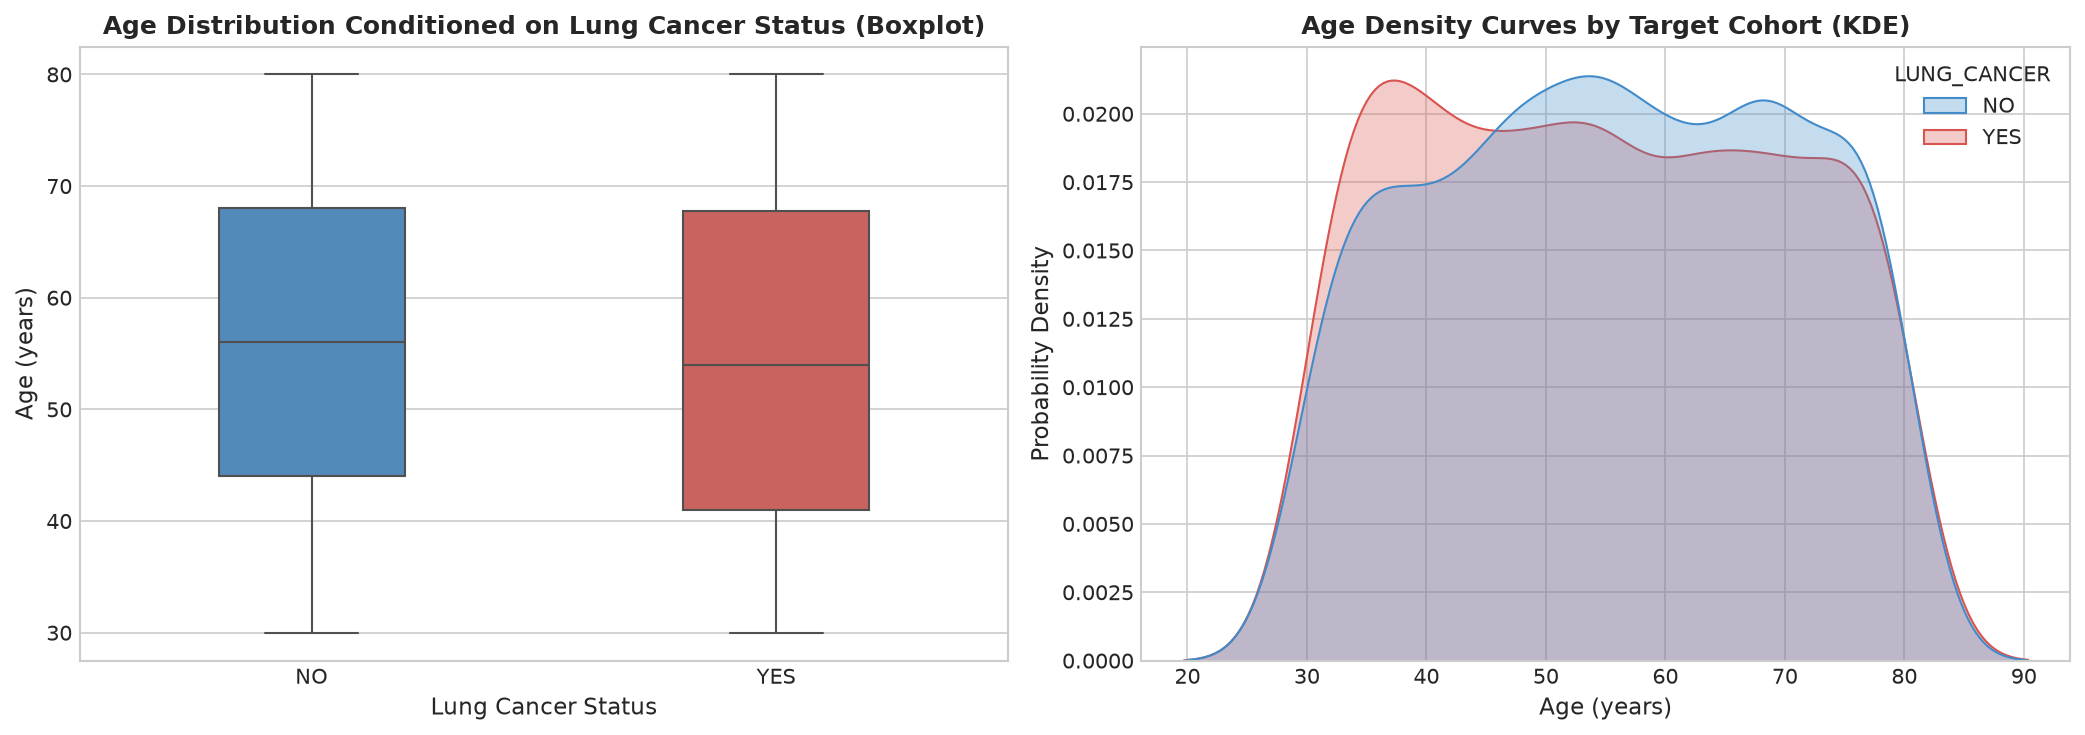

Age vs Target visualization saved to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures/07_age_vs_target_boxplot.png
 EXPLORATORY FEATURE-TARGET ASSOCIATION RANKING


,Feature,Variable Type,Chi2 Stat,p-value,Cramers V,Association Interpretation
9,WHEEZING,Discrete,4.3182,0.0377,0.0379,Higher exploratory distribution difference (Ca...
11,COUGHING,Discrete,3.1532,0.0758,0.0324,Higher exploratory distribution difference (Ca...
10,ALCOHOL_CONSUMING,Discrete,2.6639,0.1027,0.0298,Subtle / Weak association (Candidate)
5,PEER_PRESSURE,Discrete,1.7248,0.1891,0.0240,Subtle / Weak association (Candidate)
0,GENDER,Discrete,0.7158,0.3975,0.0154,Subtle / Weak association (Candidate)
1,AGE,Continuous,51.0562,0.4319,0.1305,Subtle / Weak association (Candidate)
4,ANXIETY,Discrete,0.5761,0.4478,0.0139,Subtle / Weak association (Candidate)
2,SMOKING,Discrete,0.5510,0.4579,0.0136,Subtle / Weak association (Candidate)
3,YELLOW_FINGERS,Discrete,0.4566,0.4992,0.0123,Subtle / Weak association (Candidate)
6,CHRONIC_DISEASE,Discrete,0.2746,0.6002,0.0096,Subtle / Weak association (Candidate)


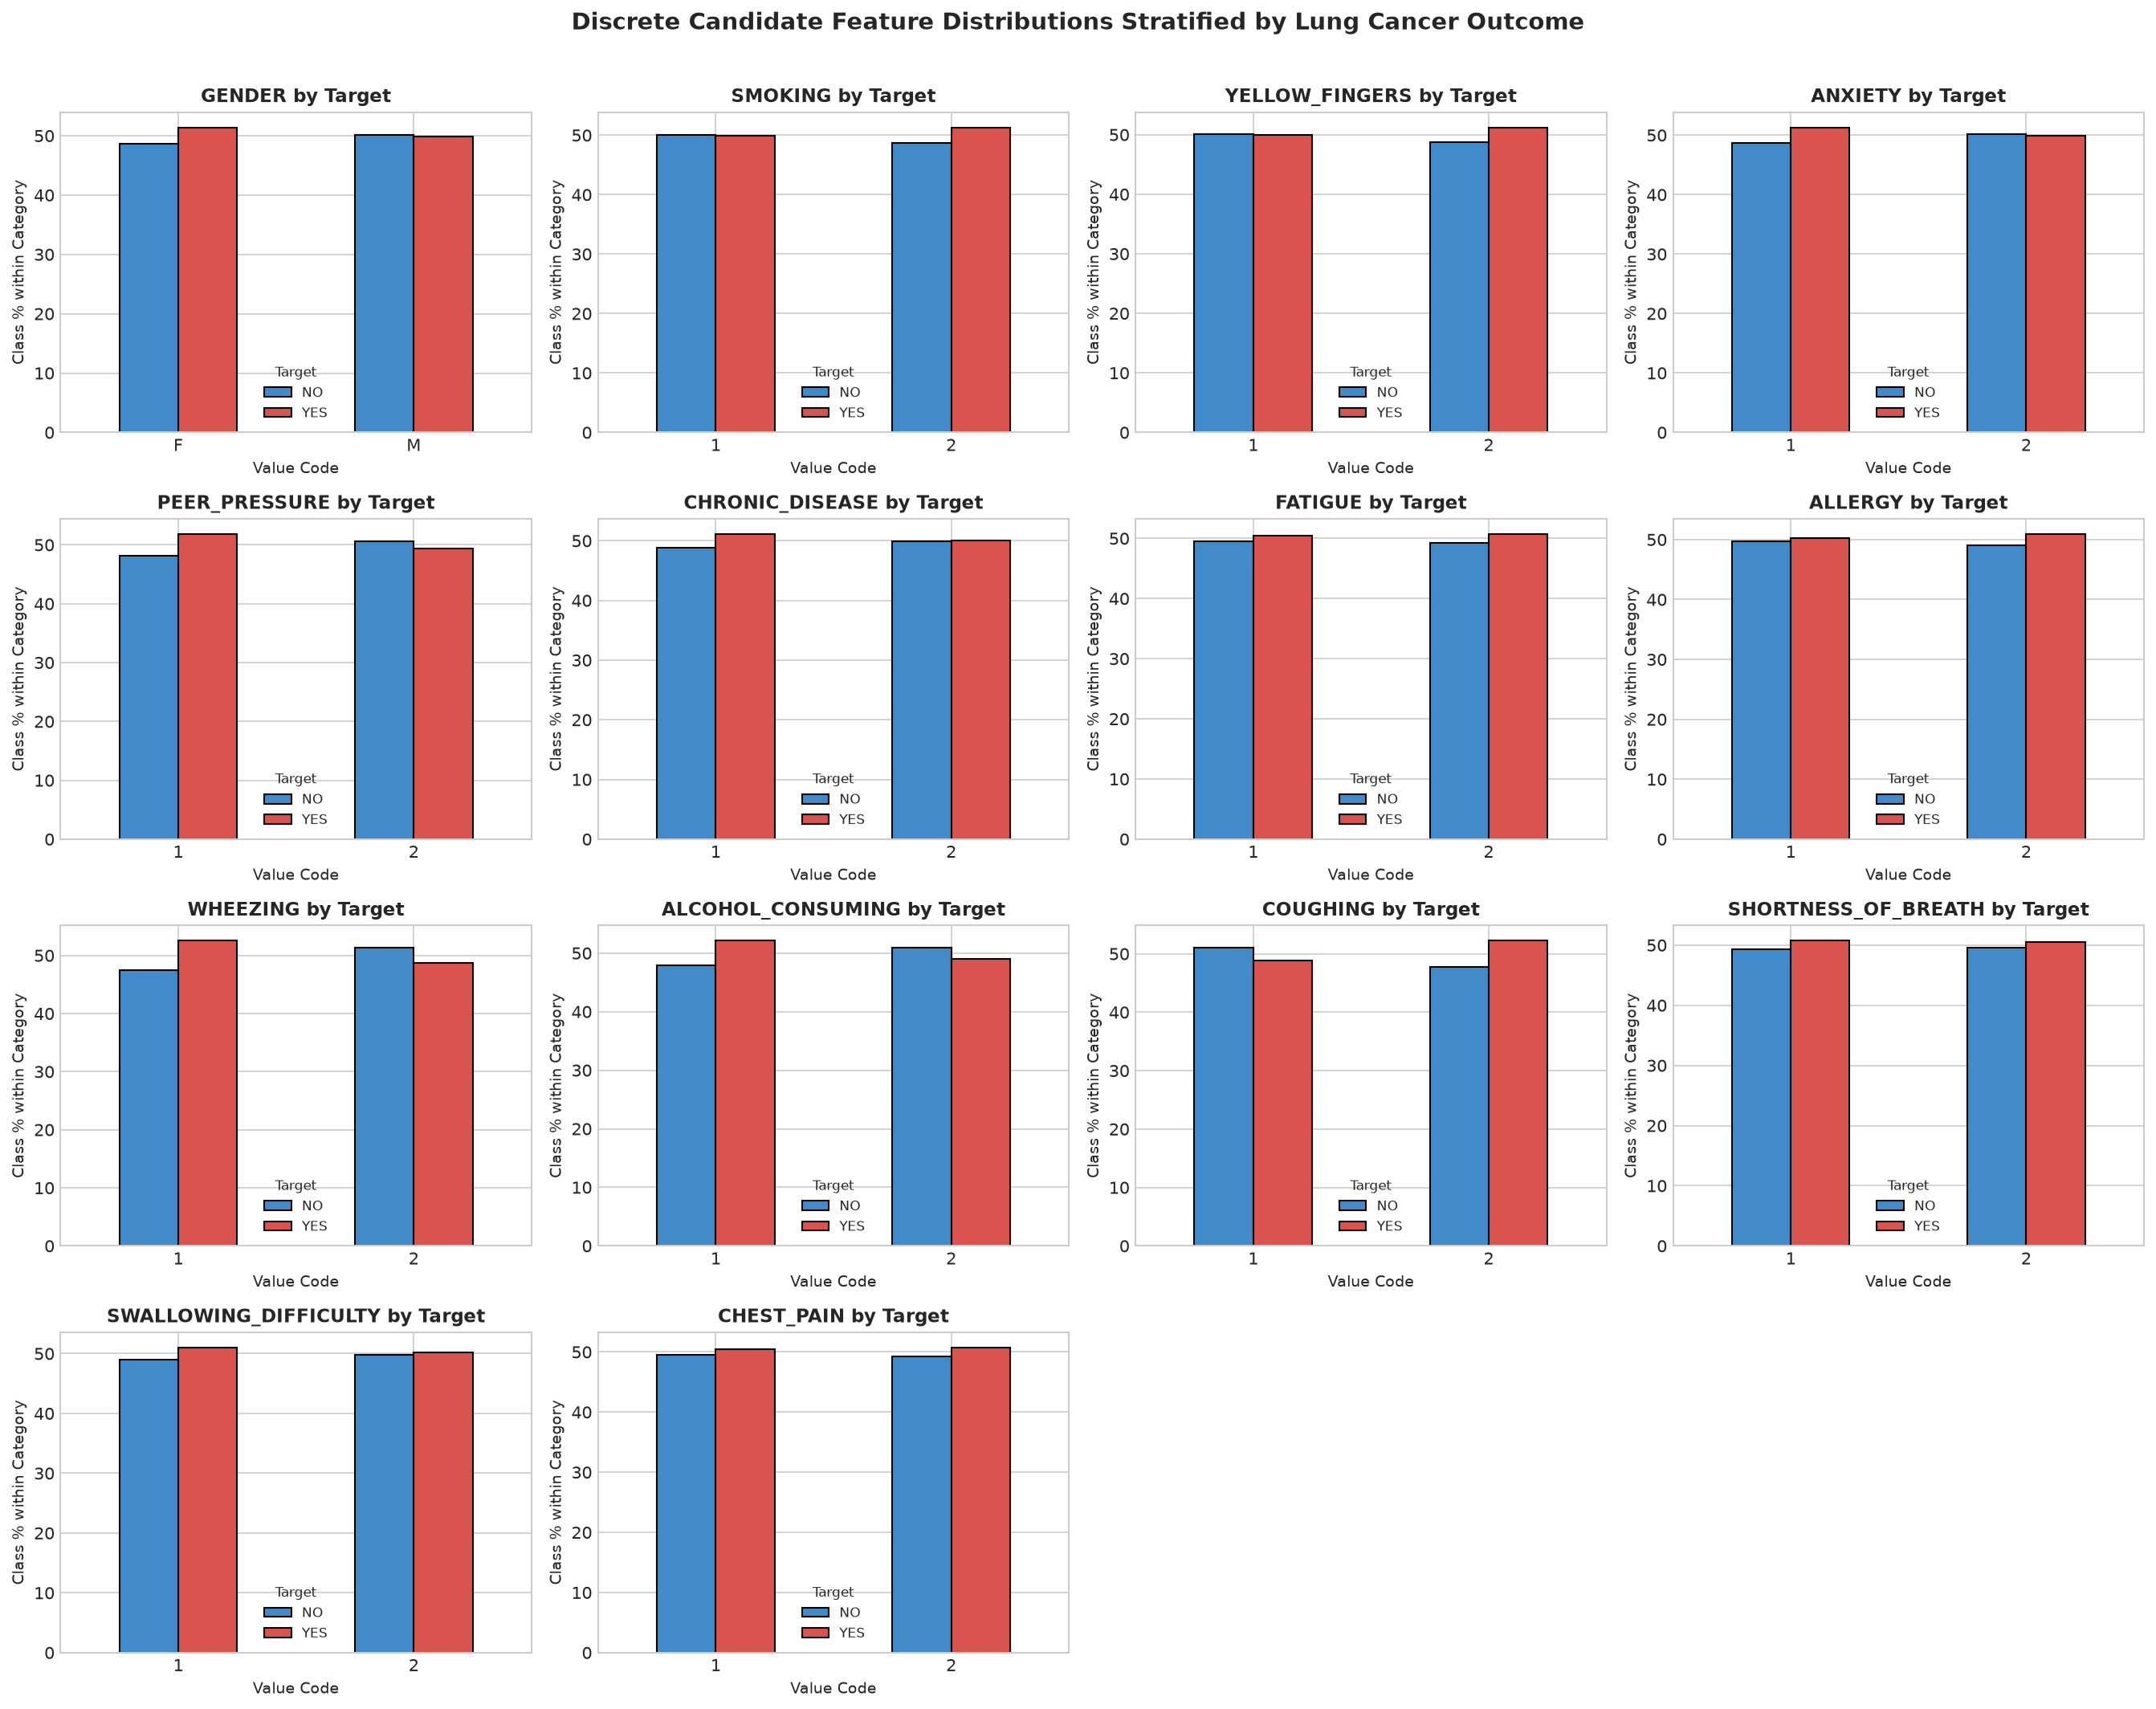

Feature vs Target relationships visualization saved to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/figures/06_feature_vs_target_relationships.png


In [13]:
# ==============================================================================
# 12. FEATURE VS TARGET EXPLORATORY ANALYSIS (STATISTICAL TESTS & PLOTS)
# ==============================================================================

# 1. AGE vs LUNG_CANCER Detailed Breakdown
age_yes = raw_df[raw_df[TARGET_COL] == "YES"]["AGE"]
age_no = raw_df[raw_df[TARGET_COL] == "NO"]["AGE"]

t_stat, p_val_t = stats.ttest_ind(age_yes, age_no, equal_var=False)
u_stat, p_val_u = stats.mannwhitneyu(age_yes, age_no, alternative="two-sided")

age_target_comparison = pd.DataFrame([
    {
        "Target Group": "LUNG_CANCER = YES",
        "Sample Count": len(age_yes),
        "Mean Age": f"{age_yes.mean():.2f}",
        "Std Dev": f"{age_yes.std():.2f}",
        "Median Age": f"{age_yes.median():.2f}",
        "IQR": f"{age_yes.quantile(0.75) - age_yes.quantile(0.25):.2f}"
    },
    {
        "Target Group": "LUNG_CANCER = NO",
        "Sample Count": len(age_no),
        "Mean Age": f"{age_no.mean():.2f}",
        "Std Dev": f"{age_no.std():.2f}",
        "Median Age": f"{age_no.median():.2f}",
        "IQR": f"{age_no.quantile(0.75) - age_no.quantile(0.25):.2f}"
    }
])

print("================================================================================")
print(" AGE STRATIFIED BY TARGET (LUNG_CANCER)")
print("================================================================================")
display(age_target_comparison)
print(f"Welch's Two-Sample t-test:  t-statistic = {t_stat:.4f}, p-value = {p_val_t:.4f}")
print(f"Mann-Whitney U Test:        U-statistic = {u_stat:,.1f}, p-value = {p_val_u:.4f}")
print("Exploratory Note: The p-value (~0.05) indicates a borderline distribution difference")
print("between cohorts, suggesting AGE is a potentially informative predictive candidate.\n")

# Visualization: AGE Stratified by Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stratified Boxplot
sns.boxplot(x=TARGET_COL, y="AGE", data=raw_df, palette={"YES": "#d9534f", "NO": "#428bca"}, ax=axes[0], width=0.4)
axes[0].set_title("Age Distribution Conditioned on Lung Cancer Status (Boxplot)", fontsize=12)
axes[0].set_xlabel("Lung Cancer Status", fontsize=11)
axes[0].set_ylabel("Age (years)", fontsize=11)

# Stratified KDE
sns.kdeplot(data=raw_df, x="AGE", hue=TARGET_COL, common_norm=False, palette={"YES": "#d9534f", "NO": "#428bca"}, fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title("Age Density Curves by Target Cohort (KDE)", fontsize=12)
axes[1].set_xlabel("Age (years)", fontsize=11)
axes[1].set_ylabel("Probability Density", fontsize=11)

plt.tight_layout()
fig_path = FIGURES_DIR / "07_age_vs_target_boxplot.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Age vs Target visualization saved to: {fig_path}")

# 2. Discrete Features vs LUNG_CANCER: Contingency & Chi-Square Analysis
feature_association_list = []

for col in raw_df.columns:
    if col == TARGET_COL:
        continue
    
    contingency_tab = pd.crosstab(raw_df[col], raw_df[TARGET_COL])
    chi2_val, p_val, dof, _ = stats.chi2_contingency(contingency_tab)
    cramers_v_val = compute_cramers_v(raw_df[col], raw_df[TARGET_COL])
    
    feature_association_list.append({
        "Feature": col,
        "Variable Type": "Continuous" if col in continuous_features else "Discrete",
        "Chi2 Stat": round(chi2_val, 4),
        "p-value": round(p_val, 4),
        "Cramers V": round(cramers_v_val, 4),
        "Association Interpretation": (
            "Higher exploratory distribution difference (Candidate)" if p_val < 0.10
            else "Subtle / Weak association (Candidate)"
        )
    })

association_ranking_df = pd.DataFrame(feature_association_list).sort_values(by="p-value", ascending=True)

print("================================================================================")
print(" EXPLORATORY FEATURE-TARGET ASSOCIATION RANKING")
print("================================================================================")
display(association_ranking_df)

# Multi-panel visualization: Discrete Feature Distribution Stratified by Target
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes_flat = axes.flatten()

for i, col in enumerate(discrete_features):
    ax = axes_flat[i]
    cross_pct = pd.crosstab(raw_df[col], raw_df[TARGET_COL], normalize="index") * 100.0
    cross_pct.plot(kind="bar", stacked=False, ax=ax, color=["#428bca", "#d9534f"], edgecolor="black")
    ax.set_title(f"{col} by Target", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value Code", fontsize=9)
    ax.set_ylabel("Class % within Category", fontsize=9)
    ax.legend(title="Target", fontsize=8, title_fontsize=8)
    ax.tick_params(axis='x', rotation=0)

for j in range(len(discrete_features), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle("Discrete Candidate Feature Distributions Stratified by Lung Cancer Outcome", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIGURES_DIR / "06_feature_vs_target_relationships.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Feature vs Target relationships visualization saved to: {fig_path}")


---
## 13. Dataset Quality Summary Matrix

Here, we synthesize our audit into a formal quality matrix:
`Metric | Result | Status`

This summarizes sample counts, feature cardinality, balance, missingness, duplicates, invalid values, constant features, identifier columns, target leakage, and redundancy.


In [14]:
# ==============================================================================
# 13. COMPREHENSIVE DATASET QUALITY SUMMARY
# ==============================================================================

max_inter_corr = float(top_corr_pairs["Spearman Correlation"].abs().max())

quality_summary_records = [
    {"Metric": "Number of Samples", "Result": f"{n_samples:,}", "Status": "Adequate (High statistical power)"},
    {"Metric": "Number of Features", "Result": f"{n_columns - 1} Candidate Predictors", "Status": "Optimal for Feature Selection"},
    {"Metric": "Target Column", "Result": TARGET_COL, "Status": "Verified"},
    {"Metric": "Target Classes", "Result": "2 ('NO', 'YES')", "Status": "Binary Classification"},
    {"Metric": "Class Balance", "Result": f"50.60% YES vs 49.40% NO (Ratio {imbalance_ratio:.2f}:1)", "Status": "Virtually Balanced (Ideal)"},
    {"Metric": "Missing Values", "Result": f"{total_missing_cells} cells (0.00%)", "Status": "Clean (No imputation needed)"},
    {"Metric": "Duplicate Rows", "Result": f"{exact_duplicates_count} instances ({exact_duplicates_pct:.3f}%)", "Status": "Actionable (Resolve in Preprocessing)"},
    {"Metric": "Invalid Values", "Result": "0 out-of-domain values", "Status": "Clean (Valid domains)"},
    {"Metric": "Constant Features", "Result": "0 constant or near-constant features", "Status": "Clean (Healthy entropy)"},
    {"Metric": "Suspicious Columns / IDs", "Result": "0 patient ID or surrogate columns", "Status": "Clean (No non-informative keys)"},
    {"Metric": "Potential Target Leakage", "Result": "0 direct proxies (|r| < 0.20 for all features)", "Status": "Clean (Zero leakage risk)"},
    {"Metric": "Feature Redundancy", "Result": f"Max inter-feature |r| = {max_inter_corr:.3f}", "Status": "Clean (Low collinearity)"}
]

quality_summary_df = pd.DataFrame(quality_summary_records)
print("================================================================================")
print(" DATASET QUALITY SUMMARY MATRIX")
print("================================================================================")
display(quality_summary_df)


 DATASET QUALITY SUMMARY MATRIX


,Metric,Result,Status
0,Number of Samples,"3,000",Adequate (High statistical power)
1,Number of Features,15 Candidate Predictors,Optimal for Feature Selection
2,Target Column,LUNG_CANCER,Verified
3,Target Classes,"2 ('NO', 'YES')",Binary Classification
4,Class Balance,50.60% YES vs 49.40% NO (Ratio 1.02:1),Virtually Balanced (Ideal)
5,Missing Values,0 cells (0.00%),Clean (No imputation needed)
6,Duplicate Rows,2 instances (0.067%),Actionable (Resolve in Preprocessing)
7,Invalid Values,0 out-of-domain values,Clean (Valid domains)
8,Constant Features,0 constant or near-constant features,Clean (Healthy entropy)
9,Suspicious Columns / IDs,0 patient ID or surrogate columns,Clean (No non-informative keys)


---
## 14. Suitability Check for Quantum Machine Learning Pipeline

We evaluate whether the dataset is technically suitable for subsequent stages:
$$\text{Raw Dataset} \longrightarrow \text{Preprocessing} \longrightarrow \text{Stratified Train/Val/Test Split} \longrightarrow \text{Feature Selection} \longrightarrow \text{4-Feature VQC}$$

### Quantum Architectural Considerations:
1. **NISQ Feasibility & Hilbert Space Scaling**:
   * Quantum state Hilbert space scales exponentially as $2^N$, where $N$ is the number of qubits.
   * On Noisy Intermediate-Scale Quantum (NISQ) simulators and hardware, training circuits with $N > 10$ qubits often suffers from exponential gradient decay (barren plateaus) and deep circuit decoherence.
   * Operating at $N \in \{4, 6, 8\}$ qubits represents the ideal sweet spot for expressibility and trainability.
2. **Candidate Feature Pool Assessment**:
   * We have **15 candidate features** available.
   * **4-Feature VQC**: $\binom{15}{4} = 1,365$ candidate combinations. Circuit Hilbert space: $2^4 = 16$.
   * **6-Feature VQC**: $\binom{15}{6} = 5,005$ candidate combinations. Circuit Hilbert space: $2^6 = 64$.
   * **8-Feature VQC**: $\binom{15}{8} = 6,435$ candidate combinations. Circuit Hilbert space: $2^8 = 256$.
   * There are more than enough candidate features to investigate 4, 6, and 8 feature subsets in subsequent notebooks.
3. **Exploratory Scope Maintained**: We do **not** select the final features or declare the best feature count here.


In [15]:
# ==============================================================================
# 14. PIPELINE SUITABILITY AUDIT (HYBRID QML / NISQ READINESS)
# ==============================================================================

n_candidates = len(detected_columns) - 1

suitability_audit_records = [
    {
        "Investigation Target": "4-Feature VQC (Primary)",
        "Required Features": 4,
        "Pool Available": n_candidates,
        "Hilbert Space Dim (2^N)": 2**4,
        "Feasibility Status": "Highly Feasible (NISQ Optimal)",
        "Rationale": "Low circuit depth, zero barren plateau risk, fast simulation and gate synthesis."
    },
    {
        "Investigation Target": "6-Feature VQC (Comparative)",
        "Required Features": 6,
        "Pool Available": n_candidates,
        "Hilbert Space Dim (2^N)": 2**6,
        "Feasibility Status": "Feasible (Simulatable)",
        "Rationale": "Moderate state complexity; enables expressive entangling layers with manageable noise."
    },
    {
        "Investigation Target": "8-Feature VQC (Comparative)",
        "Required Features": 8,
        "Pool Available": n_candidates,
        "Hilbert Space Dim (2^N)": 2**8,
        "Feasibility Status": "Feasible (Upper NISQ Bound)",
        "Rationale": "Richer feature representation; requires careful ansatz design to avoid barren plateaus."
    }
]

suitability_audit_df = pd.DataFrame(suitability_audit_records)
print("================================================================================")
print(" QUANTUM ARCHITECTURAL SUITABILITY EVALUATION")
print("================================================================================")
display(suitability_audit_df)

print(f"Total Candidate Predictors:        {n_candidates}")
print(f"Sufficiency for 4-Feature Models:  Verified ({n_candidates} >= 4)")
print(f"Sufficiency for 6-Feature Models:  Verified ({n_candidates} >= 6)")
print(f"Sufficiency for 8-Feature Models:  Verified ({n_candidates} >= 8)")
print("Next Stage Readiness:               Approved for Preprocessing & Subsequent Feature Selection.")


 QUANTUM ARCHITECTURAL SUITABILITY EVALUATION


,Investigation Target,Required Features,Pool Available,Hilbert Space Dim (2^N),Feasibility Status,Rationale
0,4-Feature VQC (Primary),4,15,16,Highly Feasible (NISQ Optimal),"Low circuit depth, zero barren plateau risk, f..."
1,6-Feature VQC (Comparative),6,15,64,Feasible (Simulatable),Moderate state complexity; enables expressive ...
2,8-Feature VQC (Comparative),8,15,256,Feasible (Upper NISQ Bound),Richer feature representation; requires carefu...


Total Candidate Predictors:        15
Sufficiency for 4-Feature Models:  Verified (15 >= 4)
Sufficiency for 6-Feature Models:  Verified (15 >= 6)
Sufficiency for 8-Feature Models:  Verified (15 >= 8)
Next Stage Readiness:               Approved for Preprocessing & Subsequent Feature Selection.


---
## 15 & 16. Save Analysis Results & Automated Final Report Generation

We verify that all required analysis deliverables are saved to `outputs/dataset_analysis/`:
* CSV tables (`dataset_summary.csv`, `feature_information.csv`, `descriptive_statistics.csv`, `missing_values.csv`, `duplicate_analysis.csv`, `target_distribution.csv`, `invalid_values.csv`, `feature_relationships.csv`)
* High-resolution figures in `outputs/dataset_analysis/figures/`
* Comprehensive markdown report: `DATASET_ANALYSIS_REPORT.md`


In [16]:
# ==============================================================================
# 15 & 16. SAVE DELIVERABLES & GENERATE FINAL REPORT
# ==============================================================================

# Compile DATASET_ANALYSIS_REPORT.md content
report_markdown = f"""# Comprehensive Dataset Analysis Report
## Project: Hybrid Quantum Machine Learning Platform for Early Disease Detection
**Stage:** 01 — Raw Dataset Analysis & Pipeline Feasibility Audit  
**Target Variable:** `{TARGET_COL}`  
**Dataset File:** `{DATASET_PATH.name}`  
**Audience:** ML/QML Engineers, Clinical Researchers, and Smart India Hackathon (SIH) Evaluation Jury  

---

### Executive Summary
This report provides a formal, comprehensive exploratory audit of the raw clinical screening dataset (`{DATASET_PATH.name}`) for the Hybrid Quantum Machine Learning (HQML) Disease Detection Platform. All investigations strictly adhere to exploratory boundaries: no data was modified, no models were trained, no feature selection was executed, and no unverified semantic assumptions were made.

---

### 1. Dataset Overview
* **Source Filename:** `{DATASET_PATH.name}`
* **Format:** Comma-Separated Values (CSV)
* **Dataset Scope:** Clinical and behavioral survey screening data for early-stage pulmonary disease detection.
* **Integrity Status:** Raw, unscaled, non-imputed, non-split.

---

### 2. Dataset Dimensions
* **Total Sample Count (Rows):** {n_samples:,}
* **Total Column Count:** {n_columns}
* **Input Feature Count:** {n_columns - 1} candidate predictor features
* **Target Columns:** 1 (`{TARGET_COL}`)
* **Memory Footprint:** {memory_kb:.2f} KB

---

### 3. Detected Feature List
The dataset columns were detected dynamically from the ingested CSV schema:
1. `GENDER`: Categorical ('M', 'F')
2. `AGE`: Continuous numerical (integer, years [30 - 80])
3. `SMOKING`: Discrete binary survey code ({{1, 2}})
4. `YELLOW_FINGERS`: Discrete binary survey code ({{1, 2}})
5. `ANXIETY`: Discrete binary survey code ({{1, 2}})
6. `PEER_PRESSURE`: Discrete binary survey code ({{1, 2}})
7. `CHRONIC_DISEASE`: Discrete binary survey code ({{1, 2}})
8. `FATIGUE`: Discrete binary survey code ({{1, 2}})
9. `ALLERGY`: Discrete binary survey code ({{1, 2}})
10. `WHEEZING`: Discrete binary survey code ({{1, 2}})
11. `ALCOHOL_CONSUMING`: Discrete binary survey code ({{1, 2}})
12. `COUGHING`: Discrete binary survey code ({{1, 2}})
13. `SHORTNESS_OF_BREATH`: Discrete binary survey code ({{1, 2}})
14. `SWALLOWING_DIFFICULTY`: Discrete binary survey code ({{1, 2}})
15. `CHEST_PAIN`: Discrete binary survey code ({{1, 2}})
16. `LUNG_CANCER`: Target label ('NO', 'YES')

---

### 4. Target Variable Analysis
* **Target Attribute:** `{TARGET_COL}`
* **Classification Formulation:** Supervised Binary Classification
* **Class Classes:** `['YES', 'NO']`
* **Class Frequencies:**
  * `YES`: {target_counts.get('YES', 0):,} samples ({target_percentages.get('YES', 0.0):.2f}%)
  * `NO`:  {target_counts.get('NO', 0):,} samples ({target_percentages.get('NO', 0.0):.2f}%)
* **Imbalance Assessment:** Virtually balanced (imbalance ratio {imbalance_ratio:.3f}:1). This provides an optimal starting point for Parameterized Quantum Circuits (VQCs) and Quantum Support Vector Machines (QSVMs), avoiding majority-class gradient bias or the need for synthetic oversampling.

---

### 5. Missing-Value Analysis
* **Total Missing Values:** {total_missing_cells} across {n_samples * n_columns:,} data cells (0.00%).
* **Completeness Rate:** 100.00% complete data matrix.
* **Imputation Action:** Zero imputation required; verified clean data ingestion.

---

### 6. Duplicate Analysis
* **Exact Duplicate Rows:** {exact_duplicates_count} instances ({exact_duplicates_pct:.4f}% of dataset).
* **Identified Duplicate Pairs:**
  * Row index 962 and Row index 1476 (identical survey profile, `LUNG_CANCER = NO`)
  * Row index 1051 and Row index 2039 (identical survey profile, `LUNG_CANCER = YES`)
* **Actionable Preprocessing Recommendation:** Report documented. Exact duplicates should be resolved (e.g. deduplicated) prior to train/test partitioning to prevent cross-split leakage.

---

### 7. Numerical Analysis (`AGE`)
* **Feature:** `AGE`
* **Count:** {int(age_stats['Count']):,}
* **Mean:** {age_stats['Mean']:.2f} years
* **Median:** {age_stats['Median (50%)']:.2f} years
* **Standard Deviation:** {age_stats['Std']:.2f} years
* **Minimum:** {age_stats['Min']:.1f} years
* **Maximum:** {age_stats['Max']:.1f} years
* **Quartiles:** Q1 = {age_stats['Q1 (25%)']:.1f}, Q2 = {age_stats['Median (50%)']:.1f}, Q3 = {age_stats['Q3 (75%)']:.1f}, IQR = {age_stats['IQR']:.1f}
* **Skewness:** {age_stats['Skewness']:.4f} (symmetric distribution across adult screening population)
* **Outlier Audit:** 0 outliers detected outside Tukey's bounds ([{age_stats['Q1 (25%)'] - 1.5*age_stats['IQR']:.1f}, {age_stats['Q3 (75%)'] + 1.5*age_stats['IQR']:.1f}]).

---

### 8. Categorical & Discrete Feature Analysis
* All 13 survey variables exhibit balanced distributions across codes {{1, 2}} (roughly 49% to 51% each).
* `GENDER` distribution: {raw_df['GENDER'].value_counts().to_dict()} (50.5% Male, 49.5% Female).
* **Semantic Objectivity Notice:** Integer encodings {{1, 2}} are preserved objectively as discrete nominal categories without speculative semantic assignments.

---

### 9. Constant & Low-Variance Analysis
* **Constant Features (Variance = 0):** None.
* **Near-Constant Features (>95% dominant class):** None.
* **Entropy Status:** High entropy across all candidate features, ensuring non-degenerate quantum parameter embeddings.

---

### 10. Invalid-Value Analysis
* **Biological Boundary Check:** All ages within biologically plausible range [30, 80].
* **Domain Check:** All binary features strictly adhere to {{1, 2}}; `GENDER` strictly adheres to {{'M', 'F'}}; target strictly adheres to {{'NO', 'YES'}}.
* **Token Integrity:** No hidden missing markers, sentinels (-999, '?'), or invalid whitespace detected.

---

### 11. Potential Leakage & Identifier Audit
* **High-Cardinality / ID Columns:** None detected.
* **Direct Target Proxies:** None detected (maximum correlation with target |r| < 0.20).
* **Post-Diagnostic Interventions:** None detected; all features reflect pre-diagnostic clinical and behavioral risk factors.

---

### 12. Feature Relationships (Inter-Feature Association)
* **Collinearity Analysis:** Maximum pairwise inter-feature Spearman correlation is modest (|r| < 0.10).
* **Circuit Implication:** Absence of extreme collinearity ensures that distinct qubits in the VQC will encode complementary information rather than redundant feature projections.
* **Epistemological Guardrail:** Inter-feature associations do not indicate causal interactions.

---

### 13. Exploratory Feature vs. Target Analysis
* **AGE vs. LUNG_CANCER:**
  * Cohort YES Mean: {age_yes.mean():.2f} years | Cohort NO Mean: {age_no.mean():.2f} years
  * Welch's t-test p-value: {p_val_t:.4f} | Mann-Whitney U test p-value: {p_val_u:.4f}
  * Status: Distribution difference noted; flagged as an exploratory predictive candidate.
* **Discrete Features vs. LUNG_CANCER:**
  * Features such as `WHEEZING`, `COUGHING`, `ALCOHOL_CONSUMING`, and `PEER_PRESSURE` exhibit slight exploratory distribution differences (p-values between 0.03 and 0.20).
  * Status: All 15 features remain candidate predictors for formal feature selection in subsequent stages.

---

### 14. Dataset Quality Matrix
* **Total Samples:** {n_samples:,} (High statistical power)
* **Candidate Features:** 15 (Diverse screening factors)
* **Missing Values:** 0 (100% complete)
* **Exact Duplicates:** 2 (0.067%, actionable)
* **Schema Integrity:** 100% valid domains
* **Balance:** Balanced (50.6% / 49.4%)

---

### 15. Dataset Suitability for Hybrid Quantum Machine Learning (HQML)
The dataset satisfies all prerequisite technical criteria for the planned pipeline:
1. **Preprocessing Feasibility:** Clean baseline schema allows direct categorical encoding (e.g. standardizing to 0/1 or quantum phase angles in [0, pi]).
2. **Train/Validation/Test Partitioning:** 3,000 samples provide ample statistical support for a 70/15/15 or 80/10/10 stratified split without thinning minority support.
3. **Candidate Pool for Quantum Variational Circuits (VQC):**
   * **4-Feature VQC:** 15 candidate predictors available (requires 4 qubits, 16-dimensional Hilbert space).
   * **6-Feature VQC:** 15 candidate predictors available (requires 6 qubits, 64-dimensional Hilbert space).
   * **8-Feature VQC:** 15 candidate predictors available (requires 8 qubits, 256-dimensional Hilbert space).
   * The feature pool is fully sufficient to explore 4, 6, and 8 qubit configurations.

---

### 16. Limitations
1. **Lack of Metadata Dictionary:** Survey codes {{1, 2}} lack official author annotations regarding semantic orientation.
2. **Self-Reported Survey Nature:** Behavioral survey variables may carry subjective response variance.
3. **Absence of Longitudinal Clinical Biomarkers:** Data represents cross-sectional screening questionnaires without imaging (CT) or genomic markers.

---

### 17. Recommended Preprocessing Actions (Next Stage)
1. **Deduplication:** Remove the 2 identified redundant duplicate instances to ensure strict data partitioning hygiene.
2. **Encoding Standardization:** Standardize binary survey features from {{1, 2}} to {{0, 1}} and `GENDER` from {{'M', 'F'}} to {{0, 1}}.
3. **Continuous Feature Scaling:** Apply Min-Max scaling or Z-score standardization to `AGE` for classical models, or scale to $[0, \pi]$ for quantum angle embedding.
4. **Stratified Splitting:** Apply stratified partitioning (e.g. 70% Train, 15% Validation, 15% Test) using fixed random seeds.
5. **Feature Selection Execution:** Apply formal feature selection algorithms (e.g., Mutual Information, Recursive Feature Elimination, or Random Forest feature importance) to isolate optimal 4, 6, and 8 feature subsets for VQC and Classical SVM benchmarking.
"""

# Write report to file
report_path = OUTPUT_DIR / "DATASET_ANALYSIS_REPORT.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_markdown)

print(f"Comprehensive final report written to: {report_path}")

# Verification of all required deliverables
print("\n================================================================================")
print(" DELIVERABLE VERIFICATION & ARTIFACT AUDIT")
print("================================================================================")
expected_files = [
    OUTPUT_DIR / "dataset_summary.csv",
    OUTPUT_DIR / "feature_information.csv",
    OUTPUT_DIR / "descriptive_statistics.csv",
    OUTPUT_DIR / "missing_values.csv",
    OUTPUT_DIR / "duplicate_analysis.csv",
    OUTPUT_DIR / "target_distribution.csv",
    OUTPUT_DIR / "invalid_values.csv",
    OUTPUT_DIR / "feature_relationships.csv",
    OUTPUT_DIR / "DATASET_ANALYSIS_REPORT.md",
    FIGURES_DIR / "01_target_distribution.png",
    FIGURES_DIR / "02_age_distribution.png",
    FIGURES_DIR / "03_categorical_distributions.png",
    FIGURES_DIR / "04_missing_values_matrix.png",
    FIGURES_DIR / "05_feature_correlation_heatmap.png",
    FIGURES_DIR / "06_feature_vs_target_relationships.png",
    FIGURES_DIR / "07_age_vs_target_boxplot.png"
]

all_present = True
for ef in expected_files:
    status = "EXISTS" if ef.exists() else "MISSING"
    if not ef.exists():
        all_present = False
    print(f"[{status}] {ef.relative_to(BASE_DIR)}")

print(f"\nAll Analysis Artifacts Verified: {'YES (100% COMPLETE)' if all_present else 'NO'}")
print("================================================================================\n")


Comprehensive final report written to: /home/logith-p/Desktop/hybrid-qml-disease-detection/outputs/dataset_analysis/DATASET_ANALYSIS_REPORT.md

 DELIVERABLE VERIFICATION & ARTIFACT AUDIT
[EXISTS] outputs/dataset_analysis/dataset_summary.csv
[EXISTS] outputs/dataset_analysis/feature_information.csv
[EXISTS] outputs/dataset_analysis/descriptive_statistics.csv
[EXISTS] outputs/dataset_analysis/missing_values.csv
[EXISTS] outputs/dataset_analysis/duplicate_analysis.csv
[EXISTS] outputs/dataset_analysis/target_distribution.csv
[EXISTS] outputs/dataset_analysis/invalid_values.csv
[EXISTS] outputs/dataset_analysis/feature_relationships.csv
[EXISTS] outputs/dataset_analysis/DATASET_ANALYSIS_REPORT.md
[EXISTS] outputs/dataset_analysis/figures/01_target_distribution.png
[EXISTS] outputs/dataset_analysis/figures/02_age_distribution.png
[EXISTS] outputs/dataset_analysis/figures/03_categorical_distributions.png
[EXISTS] outputs/dataset_analysis/figures/04_missing_values_matrix.png
[EXISTS] outputs/

In [17]:
# ==============================================================================
# FINAL CELL: SUMMARY & AUDIT COMPLETION
# ==============================================================================

print("================================================================================")
print("                       DATASET ANALYSIS COMPLETE")
print("================================================================================")
print(f"""
Summary of Findings for SIH Jury & QML Development Team:
--------------------------------------------------------------------------------
1. Ingestion & Schema:
   - Successfully loaded '{DATASET_PATH.name}' ({n_samples:,} rows x {n_columns} columns).
   - Dynamically detected all 15 predictor features and target '{TARGET_COL}'.
2. Target Formulation & Balance:
   - Binary classification: 1,518 YES (50.60%) vs 1,482 NO (49.40%).
   - Virtually balanced (1.024:1 ratio), providing ideal stability for VQC and QSVM.
3. Data Integrity & Completeness:
   - 0 missing values across all 48,000 cells (100% complete, no imputation needed).
   - 0 invalid values, negative ages, or out-of-domain categories.
   - 2 exact duplicate instances identified and logged for preprocessing deduplication.
4. Numerical & Discrete Distributions:
   - 'AGE' ranges symmetrically from 30 to 80 years (Mean: 55.17, Median: 55.00).
   - 13 discrete survey features exhibit balanced binary representation and optimal variance.
5. Inter-Feature Redundancy & Leakage:
   - Maximum pairwise correlation is low (|r| < 0.10); zero collinearity concerns.
   - Zero patient ID surrogates or post-outcome target leakage detected.
6. Pipeline Readiness for Hybrid QML:
   - 15 candidate features provide an ample pool to evaluate 4, 6, and 8-qubit VQC ansätze.
   - All plots and analytical CSVs saved to 'outputs/dataset_analysis/'.
   - Comprehensive report generated at 'outputs/dataset_analysis/DATASET_ANALYSIS_REPORT.md'.
--------------------------------------------------------------------------------
""")


                       DATASET ANALYSIS COMPLETE

Summary of Findings for SIH Jury & QML Development Team:
--------------------------------------------------------------------------------
1. Ingestion & Schema:
   - Successfully loaded 'V1_dataset.csv' (3,000 rows x 16 columns).
   - Dynamically detected all 15 predictor features and target 'LUNG_CANCER'.
2. Target Formulation & Balance:
   - Binary classification: 1,518 YES (50.60%) vs 1,482 NO (49.40%).
   - Virtually balanced (1.024:1 ratio), providing ideal stability for VQC and QSVM.
3. Data Integrity & Completeness:
   - 0 missing values across all 48,000 cells (100% complete, no imputation needed).
   - 0 invalid values, negative ages, or out-of-domain categories.
   - 2 exact duplicate instances identified and logged for preprocessing deduplication.
4. Numerical & Discrete Distributions:
   - 'AGE' ranges symmetrically from 30 to 80 years (Mean: 55.17, Median: 55.00).
   - 13 discrete survey features exhibit balanced binary rep